[FONT] 적용: Malgun Gothic @ C:\Windows\Fonts\malgun.ttf
[INFO] 사용 폰트: Malgun Gothic
[INFO] Columns: ['category_url', 'product_name', 'brand', 'product_url', 'price', 'review_count', 'review_date', 'review_text']
[INFO] 상품명 컬럼: product_name
[INFO] 텍스트 컬럼: ['review_count', 'review_date', 'review_text']
[INFO] Komoran 로드 OK
[DONE] 전체 분석 PNG/CSV 저장
[INFO] 스트레스 관리: 95 rows
[INFO] 수면: 0 rows
[INFO] 장 건강/유산균: 10 rows
[INFO] 멀티비타민: 270 rows
[INFO] 비타민 D: 85 rows
[INFO] 피부/항산화: 98 rows
[INFO] 혈액/피로: 80 rows
[INFO] 면역력: 128 rows
[INFO] 체지방 관리: 0 rows
[INFO] 스포츠 영양: 50 rows


C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3247348768.py:261: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(co, aspect="auto")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3247348768.py:261: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(co, aspect="auto")


FileNotFoundError: [Errno 2] No such file or directory: 'out_kurly_morph\\장_건강/유산균_heatmap.png'

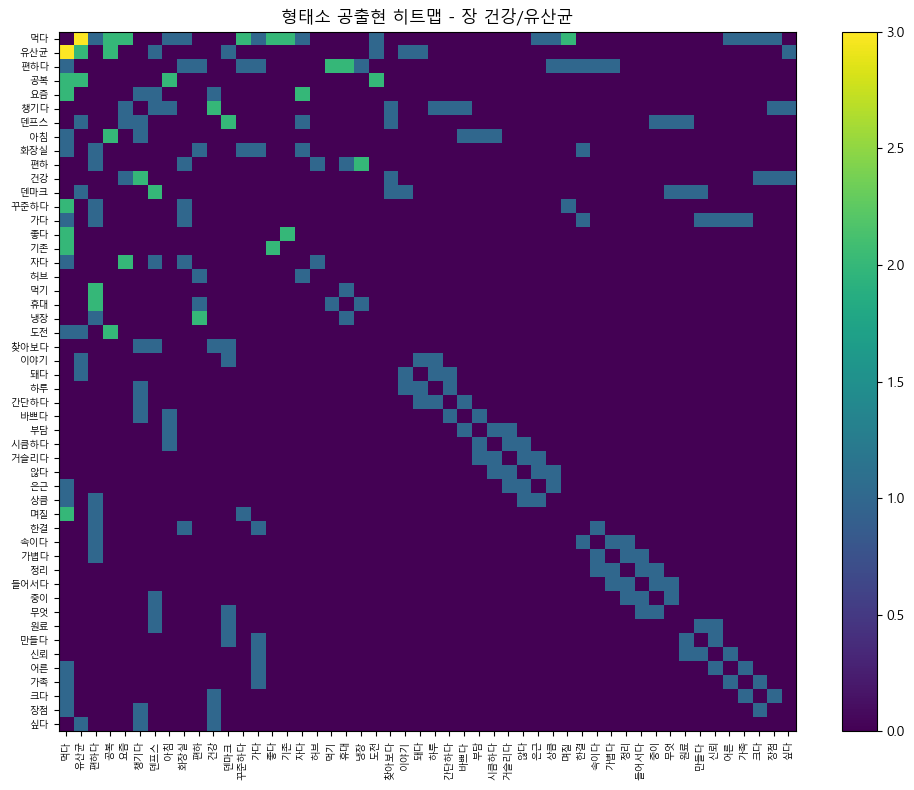

In [5]:
# -*- coding: utf-8 -*-
# Kurly 건강 데이터 형태소/관계 분석 (전체 & 카테고리별)
# - 주피터 노트북에서 실행
# - 입력: /mnt/data/kurly_health_merged_20250922_2109.csv
# - 출력: out_kurly_morph/ (PNG, CSV 모두 utf-8-sig)

# ========== 0) 의존성 ==========
# 필요한 경우만 실행:
# !pip -q install konlpy scikit-learn pandas numpy matplotlib

# Komoran은 Java 필요(Colab/Linux 등):
# !apt-get -y update && apt-get -y install default-jdk

import os, re, unicodedata, math, json, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm, rcParams, ft2font
from sklearn.decomposition import PCA
from IPython.display import display

# ========== 1) 한글 폰트 보장 ==========
CUSTOM_FONT_PATH = ""  # 필요 시 TTF/OTF 경로 지정 (예: r"C:\Windows\Fonts\malgun.ttf")

def _has_korean_glyph(font_path: str) -> bool:
    try:
        f = ft2font.FT2Font(font_path)
        cmap = f.get_charmap()
        return (ord("가") in cmap) and (ord("한") in cmap)
    except Exception:
        return False

def ensure_korean_font():
    if CUSTOM_FONT_PATH and os.path.exists(CUSTOM_FONT_PATH) and _has_korean_glyph(CUSTOM_FONT_PATH):
        fm.fontManager.addfont(CUSTOM_FONT_PATH)
        fam = fm.FontProperties(fname=CUSTOM_FONT_PATH).get_name()
        rcParams["font.family"] = [fam]
        rcParams["axes.unicode_minus"] = False
        try: fm._load_fontmanager(try_read_cache=False)
        except Exception: pass
        print(f"[FONT] 사용자 지정: {fam} @ {CUSTOM_FONT_PATH}")
        return fam

    preferred_names = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]
    for fam in preferred_names:
        try:
            path = fm.findfont(fam, fallback_to_default=False)
            if os.path.exists(path) and _has_korean_glyph(path):
                rcParams["font.family"] = [fam]
                rcParams["axes.unicode_minus"] = False
                print(f"[FONT] 적용: {fam} @ {path}")
                return fam
        except Exception:
            pass

    # 파일 경로 후보
    candidates = [
        r"C:\Windows\Fonts\malgun.ttf",
        "/Library/Fonts/AppleGothic.ttf",
        "/System/Library/Fonts/AppleSDGothicNeo.ttc",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/noto/NotoSansKR-Regular.otf",
    ]
    for p in candidates:
        if os.path.exists(p) and _has_korean_glyph(p):
            fm.fontManager.addfont(p)
            fam = fm.FontProperties(fname=p).get_name()
            rcParams["font.family"] = [fam]
            rcParams["axes.unicode_minus"] = False
            try: fm._load_fontmanager(try_read_cache=False)
            except Exception: pass
            print(f"[FONT] 파일 적용: {fam} @ {p}")
            return fam

    rcParams["font.family"] = ["DejaVu Sans", "Arial", "Sans-serif"]
    rcParams["axes.unicode_minus"] = False
    warnings.warn("⚠️ 한글 글리프 폰트를 찾지 못했습니다. CUSTOM_FONT_PATH를 지정하세요.")
    return rcParams["font.family"]

FONT_USED = ensure_korean_font()
print("[INFO] 사용 폰트:", FONT_USED)

# ========== 2) 데이터 로드 ==========
DATA_PATH = "kurly_health_merged_20250922_2109.csv"
OUTPUT_DIR = "out_kurly_morph"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def read_csv_safely(path):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    return pd.read_csv(path, engine="python")

df = read_csv_safely(DATA_PATH)
print("[INFO] Columns:", list(df.columns))

# 텍스트/상품명 컬럼 자동탐지
def _find_col(cands):
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in cands): return c
    return None

PRODUCT_COL = _find_col(["상품","product","item","제품","name","title"])
text_cols   = [c for c in df.columns if any(k in str(c).lower() for k in ["리뷰","후기","review","text","내용","comment","설명","평"])]
if not text_cols:
    text_cols = [PRODUCT_COL] if PRODUCT_COL else []
print(f"[INFO] 상품명 컬럼: {PRODUCT_COL}")
print(f"[INFO] 텍스트 컬럼: {text_cols}")

def combine_text(row):
    parts=[]
    for c in text_cols:
        v = row.get(c,"")
        if pd.isna(v): continue
        parts.append(str(v))
    return " ".join(parts).strip()

df["_merged_text"] = df.apply(combine_text, axis=1)

# ========== 3) Okt + Komoran + 사용자 사전 ==========
from konlpy.tag import Okt
okt = Okt()

USER_TERMS = [
    "테아닌","L-테아닌","l-테아닌","l테아닌","아슈와간다","Ashwagandha",
    "로디올라","Rhodiola","홍경천","멜라토닌","Melatonin","발레리안","Valerian",
    "GABA","가바","마그네슘","Magnesium","트립토판","L-트립토판","글리신","Glycine",
    "프로바이오틱스","프리바이오틱스","포스트바이오틱스","유산균",
    "락토바실러스","Lactobacillus","비피도박테리움","Bifidobacterium",
    "비타민D","D3","Cholecalciferol","비타민C","비타민E","코큐텐","CoQ10",
    "아연","베타글루칸","프로폴리스","홍삼","가르시니아","HCA","EGCG",
    "카르니틴","CLA","BCAA","EAA","크레아틴","웨이","Whey","단백질"
]
for t in USER_TERMS:
    try: okt.add_dictionary(t, 'Noun')
    except Exception: pass

USER_DIC_PATH = os.path.join(OUTPUT_DIR, "komoran_user_dict.txt")
with open(USER_DIC_PATH, "w", encoding="utf-8") as f:
    for t in USER_TERMS: f.write(f"{t}\tNNP\n")

try:
    from konlpy.tag import Komoran
    komoran = Komoran(userdic=USER_DIC_PATH)
    print("[INFO] Komoran 로드 OK")
except Exception as e:
    komoran = None
    print("[WARN] Komoran 사용 불가(Java 필요). Okt만 사용:", e)

# ========== 4) 토큰화/정규화/동의어 ==========
BASE_STOP = set("""
그리고 그러나 그런데 또한 또는 그래서 때문에 등의 즉 및 으로 로 은 는 이 가 을 를 과 와 하고 보다 에서 에게 에 에도 에는 에다가 으니까 면 도 만 까지 뿐 처럼 같은 듯 듯이 것 거 데 수 들 등 더 가장 제일 아주 매우 너무 정말 진짜 그냥 혹시 거의 대부분 여러 각각 모든 아무 이런 그런 저런 어떤 무슨 있다 없다 이다 아니다 하다 되다 같다
제품 상품 구성 구입 구매 배송 포장 가격 행사 세트 옵션 용량 맛 향 느낌 사용 효과 후기 리뷰 평가 별점 평점 추천 만족 불만 개선 재구매 성분 브랜드
수량 개 수 박스 병 캡슐 정 분 알 가루 분말 ml mg g kg 개입 세일 이벤트 증정 사은품먹다 좋다 선물 자다 주문 챙기다 챙기 먹기 맛있다 건강 젤리 맛있 편하다 멀티 편하
꾸준하다 하루 들다 사다 알약 섭취 받다 양제 않다 아침 쇼핑 한번 드리 쇼핑백 드리다 가다 남편 피곤하다 크기 괜찮다 되어다 요즘 복용 할인 종이 괜찮 간편하다 함량 고객
부담 필요
""".split())
DOMAIN_STOP = set("""
비타민 멀티비타민 미네랄 영양제 건강기능식품 건강기능 식품 기능 기능식품
남성 여성 성인 남자 여자 아이 어린이 임산부 시니어
국산 해외 직구 마켓 컬리 마켓컬리 이너컬리 컬리
정기 구독 무료 빠른 오늘 내일 도착 출고 배송비
""".split())
KEEP = {"간편하다","다이어트"}  # CSV 파일 변환 저장 조건

UNIFY = {
    "ashwagandha":"아슈와간다","아쉬와간다":"아슈와간다",
    "rhodiola":"로디올라","rosea":"로디올라","홍경천":"로디올라",
    "l-테아닌":"테아닌","l테아닌":"테아닌","l-theanine":"테아닌","theanine":"테아닌",
    "melatonin":"멜라토닌","valerian":"발레리안","gaba":"가바","magnesium":"마그네슘",
    "glycine":"글리신","tryptophan":"트립토판","l-tryptophan":"트립토판",
    "probiotic":"프로바이오틱스","probiotics":"프로바이오틱스",
    "prebiotic":"프리바이오틱스","prebiotics":"프리바이오틱스",
    "postbiotic":"포스트바이오틱스","postbiotics":"포스트바이오틱스",
    "lactobacillus":"락토바실러스","bifidobacterium":"비피도박테리움",
    "d3":"비타민D","cholecalciferol":"비타민D","vitamin d":"비타민D","vitamind":"비타민D",
    "vitamin c":"비타민C","vitamin e":"비타민E",
    "b6":"비타민B6","b-6":"비타민B6","vitamin b6":"비타민B6",
    "b12":"비타민B12","b-12":"비타민B12","vitamin b12":"비타민B12",
    "coq10":"코큐텐","q10":"코큐텐",
    "hca":"가르시니아","egcg":"EGCG","cla":"CLA","whey":"웨이",
    "bcaa":"BCAA","eaa":"EAA","creatine":"크레아틴","protein":"단백질"
}

def _normalize(tok:str)->str:
    t = tok.strip().replace("\u200b","")
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"^[^\w가-힣]+|[^\w가-힣]+$", "", t)
    if not t: return ""
    if re.search(r"[A-Za-z]", t): t = t.lower()
    rep = [("했습니다","하다"),("합니다","하다"),("했어요","하다"),("해요","하다"),("했다","하다"),
           ("됩니다","되다"),("된다","되다"),("됐어요","되다"),
           ("같아요","같다"),("좋아요","좋다")]
    for suf, root in rep:
        if t.endswith(suf): t = t[:len(t)-len(suf)] + root; break
    if len(t)==1 and not re.fullmatch(r"[0-9a-z]", t): return ""
    return t

def _unify(t:str)->str:
    return UNIFY.get(t.lower(), t)

def _filter(tokens):
    out=[]
    for t in tokens:
        if t in KEEP: out.append(t); continue
        if t in BASE_STOP or t in DOMAIN_STOP: continue
        if re.fullmatch(r"[0-9]+", t): continue
        out.append(t)
    return out

def tok_okt(text:str):
    return [w for w,p in okt.pos(text, norm=True, stem=True) if p in {"Noun","Adjective","Verb"}]

def tok_komoran(text:str):
    if komoran is None: return []
    return [w for w,p in komoran.pos(text) if p in {"NNP","NNG","VA","VV"}]

def tokenize(text:str):
    if not isinstance(text,str) or not text.strip(): return []
    s = unicodedata.normalize("NFKC", text)
    toks=[]
    try: toks += tok_okt(s)
    except Exception: pass
    try: toks += tok_komoran(s)
    except Exception: pass
    if not toks:
        toks = re.findall(r"[가-힣A-Za-z0-9\-]+", s)
    toks = [_normalize(t) for t in toks if t]
    toks = [_unify(t) for t in toks if t]
    toks = _filter(toks)
    return toks

# 전체 토큰화
docs = df["_merged_text"].fillna("").tolist()
tok_docs = [tokenize(t) for t in docs]

# ========== 5) 공출현/시각화 ==========
def build_cooc(token_docs, top_n=50, window=3):
    tf = Counter()
    for tks in token_docs: tf.update(tks)
    terms = [w for w,_ in tf.most_common(top_n)]
    idx = {w:i for i,w in enumerate(terms)}
    co = np.zeros((len(terms), len(terms)), dtype=np.int64)
    for tks in token_docs:
        for i,w in enumerate(tks):
            if w not in idx: continue
            wi = idx[w]
            for j in range(i+1, min(i+window, len(tks))):
                v = tks[j]
                if v not in idx: continue
                vi = idx[v]
                co[wi,vi]+=1; co[vi,wi]+=1
    return terms, tf, co

def plot_heatmap(terms, co, title, out_png, dpi=300):
    plt.figure(figsize=(10,8))
    plt.imshow(co, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(terms)), terms, rotation=90, fontsize=7)
    plt.yticks(range(len(terms)), terms, fontsize=7)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.close()

def plot_bubble(terms, tf, co, title, out_png, dpi=300):
    if len(terms) < 2: return
    coords = PCA(n_components=2, random_state=42).fit_transform(co + np.eye(co.shape[0])*1e-6)
    freqs = np.array([tf[t] for t in terms]); sizes = 220*(freqs/max(freqs))**0.6
    plt.figure(figsize=(8,6))
    plt.scatter(coords[:,0], coords[:,1], s=sizes, alpha=0.6)
    for i, term in enumerate(terms):
        plt.text(coords[i,0], coords[i,1], term, fontsize=8)
    plt.title(title); plt.xlabel("PCA-1"); plt.ylabel("PCA-2")
    plt.tight_layout()
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.close()

def save_terms_csv(terms, tf, out_csv):
    pd.DataFrame({"term":terms, "freq":[tf[t] for t in terms]}).to_csv(out_csv, index=False, encoding="utf-8-sig")

# 전체 분석
TOP_N, WIN = 50, 3
terms_all, tf_all, co_all = build_cooc(tok_docs, top_n=TOP_N, window=WIN)
plot_heatmap(terms_all, co_all, "형태소 공출현 히트맵 (전체)", os.path.join(OUTPUT_DIR,"overall_heatmap.png"))
plot_bubble(terms_all, tf_all, co_all, "형태소 관계 버블차트 (전체)", os.path.join(OUTPUT_DIR,"overall_bubble.png"))
save_terms_csv(terms_all, tf_all, os.path.join(OUTPUT_DIR,"overall_top_terms.csv"))
print("[DONE] 전체 분석 PNG/CSV 저장")

# ========== 6) 카테고리(이미지 볼드 10개) ==========
CATEGORIES = {
    "스트레스 관리": [
        "스트레스","긴장","집중","컨디션","피로","아슈와간다","ashwagandha",
        "로디올라","홍경천","테아닌","l-테아닌","gaba","마그네슘","비타민b6","비타민b12","코르티솔"
    ],
    "수면": [
        "수면","숙면","불면","멜라토닌","테아닌","gaba","글리신","트립토판","카모마일","라벤더","발레리안"
    ],
    "장 건강/유산균": [
        "장","유산균","프로바이오틱스","프리바이오틱스","포스트바이오틱스","락토바실러스","비피도박테리움","Lactobacillus","Bifidobacterium"
    ],
    "멀티비타민": ["멀티비타민","종합비타민","multivitamin"],
    "비타민 D": ["비타민d","d3","cholecalciferol","k2","mk-7"],
    "피부/항산화": ["피부","콜라겐","엘라스틴","히알루론산","비타민c","비타민e","코큐텐","항산화","루테인","아스타잔틴"],
    "혈액/피로": ["혈액","헤모글로빈","철분","에너지","코큐텐","비타민b12","홍삼"],
    "면역력": ["면역","아연","비타민c","베타글루칸","프로폴리스","홍삼"],
    "체지방 관리": ["감량","다이어트","가르시니아","hca","cla","egcg","카르니틴","레몬밤","로즈마린산"],
    "스포츠 영양": ["단백질","프로틴","웨이","whey","bcaa","eaa","크레아틴","카페인","젤","이소토닉"],
}

def _norm_str(s):
    s = "" if s is None else str(s)
    s = unicodedata.normalize("NFKC", s)
    return s, s.lower()

def _match_cat(name, keys):
    s, sl = _norm_str(name)
    for k in keys:
        k2 = unicodedata.normalize("NFKC", k)
        if (k2 in s) or (k2.lower() in sl): return True
    return False

if PRODUCT_COL is None:
    print("[WARN] 상품명 컬럼 없음 → 전체로 처리")
    cat_frames = {k: df.copy() for k in CATEGORIES}
else:
    cat_frames = {}
    for cat, keys in CATEGORIES.items():
        mask = df[PRODUCT_COL].astype(str).apply(lambda x: _match_cat(x, keys))
        cat_frames[cat] = df[mask].copy()
        print(f"[INFO] {cat}: {cat_frames[cat].shape[0]} rows")

# 카테고리별 분석/저장
summary_rows = []
for cat, sub in cat_frames.items():
    docs = sub["_merged_text"].fillna("").tolist()
    tdocs = [tokenize(t) for t in docs]
    terms, tf, co = build_cooc(tdocs, top_n=TOP_N, window=WIN)

    hp = os.path.join(OUTPUT_DIR, f"{cat}_heatmap.png").replace(" ","_")
    bp = os.path.join(OUTPUT_DIR, f"{cat}_bubble.png").replace(" ","_")
    cp = os.path.join(OUTPUT_DIR, f"{cat}_top_terms.csv").replace(" ","_")

    plot_heatmap(terms, co, f"형태소 공출현 히트맵 - {cat}", hp)
    plot_bubble(terms, tf, co, f"형태소 관계 버블차트 - {cat}", bp)
    save_terms_csv(terms, tf, cp)

    summary_rows.append({"category":cat, "num_rows":len(sub), "heatmap_png":hp, "bubble_png":bp, "top_terms_csv":cp})

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUTPUT_DIR, "category_summary.csv")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
display(summary_df)
print("[DONE] 카테고리별 PNG/CSV 저장 →", os.path.abspath(OUTPUT_DIR))


In [8]:
# -*- coding: utf-8 -*-
# Kurly 건강 데이터 형태소/관계 분석 (전체 & 카테고리별)
# - 에러 수정: 카테고리명 파일경로 안전화 + 빈 공출현 처리
# - TOP_N=100으로 확장

# ========== 0) 의존성 ==========
# !pip -q install konlpy scikit-learn pandas numpy matplotlib
# (Komoran은 Java 필요)  # !apt-get -y update && apt-get -y install default-jdk

import os, re, unicodedata, math, json, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm, rcParams, ft2font
from sklearn.decomposition import PCA
from IPython.display import display

# ========== 1) 한글 폰트 보장 ==========
CUSTOM_FONT_PATH = ""  # 예: r"C:\Windows\Fonts\malgun.ttf"

def _has_korean_glyph(font_path: str) -> bool:
    try:
        f = ft2font.FT2Font(font_path); cmap = f.get_charmap()
        return (ord("가") in cmap) and (ord("한") in cmap)
    except Exception:
        return False

def ensure_korean_font():
    if CUSTOM_FONT_PATH and os.path.exists(CUSTOM_FONT_PATH) and _has_korean_glyph(CUSTOM_FONT_PATH):
        fm.fontManager.addfont(CUSTOM_FONT_PATH)
        fam = fm.FontProperties(fname=CUSTOM_FONT_PATH).get_name()
        rcParams["font.family"] = [fam]; rcParams["axes.unicode_minus"] = False
        try: fm._load_fontmanager(try_read_cache=False)
        except Exception: pass
        print(f"[FONT] 사용자 지정: {fam} @ {CUSTOM_FONT_PATH}"); return fam
    for fam in ["Malgun Gothic","AppleGothic","NanumGothic","Noto Sans CJK KR","Noto Sans KR"]:
        try:
            path = fm.findfont(fam, fallback_to_default=False)
            if os.path.exists(path) and _has_korean_glyph(path):
                rcParams["font.family"] = [fam]; rcParams["axes.unicode_minus"] = False
                print(f"[FONT] 적용: {fam} @ {path}"); return fam
        except Exception: pass
    for p in [r"C:\Windows\Fonts\malgun.ttf","/Library/Fonts/AppleGothic.ttf",
              "/System/Library/Fonts/AppleSDGothicNeo.ttc",
              "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
              "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
              "/usr/share/fonts/truetype/noto/NotoSansKR-Regular.otf"]:
        if os.path.exists(p) and _has_korean_glyph(p):
            fm.fontManager.addfont(p)
            fam = fm.FontProperties(fname=p).get_name()
            rcParams["font.family"] = [fam]; rcParams["axes.unicode_minus"] = False
            try: fm._load_fontmanager(try_read_cache=False)
            except Exception: pass
            print(f"[FONT] 파일 적용: {fam} @ {p}"); return fam
    rcParams["font.family"] = ["DejaVu Sans","Arial","Sans-serif"]; rcParams["axes.unicode_minus"] = False
    warnings.warn("⚠️ 한글 글리프 폰트를 찾지 못했습니다. CUSTOM_FONT_PATH를 지정하세요.")
    return rcParams["font.family"]

FONT_USED = ensure_korean_font()
print("[INFO] 사용 폰트:", FONT_USED)

# ========== 2) 경로/유틸 ==========
DATA_PATH  = "kurly_health_merged_20250922_2109.csv"   # 필요 시 수정
OUTPUT_DIR = "out_kurly_morph"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def safe_filename(name: str) -> str:
    """파일명으로 안전하게 치환 (슬래시 등 금지문자 → '_')."""
    s = unicodedata.normalize("NFKC", str(name))
    s = re.sub(r'[\\/:*?"<>|\s]+', "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "untitled"

def read_csv_safely(path):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try: return pd.read_csv(path, encoding=enc)
        except Exception: continue
    return pd.read_csv(path, engine="python")

df = read_csv_safely(DATA_PATH)
print("[INFO] Columns:", list(df.columns))

# 텍스트/상품명 컬럼 자동탐지
def _find_col(cands):
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in cands): return c
    return None

PRODUCT_COL = _find_col(["상품","product","item","제품","name","title"])
text_cols   = [c for c in df.columns if any(k in str(c).lower() for k in ["리뷰","후기","review","text","내용","comment","설명","평"])]
if not text_cols: text_cols = [PRODUCT_COL] if PRODUCT_COL else []
print(f"[INFO] 상품명 컬럼: {PRODUCT_COL}")
print(f"[INFO] 텍스트 컬럼: {text_cols}")

def combine_text(row):
    parts=[]; 
    for c in text_cols:
        v = row.get(c,""); 
        if pd.isna(v): continue
        parts.append(str(v))
    return " ".join(parts).strip()

df["_merged_text"] = df.apply(combine_text, axis=1)

# ========== 3) Okt + Komoran + 사용자 사전 ==========
from konlpy.tag import Okt
okt = Okt()

USER_TERMS = [
    "테아닌","L-테아닌","l-테아닌","l테아닌","아슈와간다","Ashwagandha",
    "로디올라","Rhodiola","홍경천","멜라토닌","Melatonin","발레리안","Valerian",
    "GABA","가바","마그네슘","Magnesium","트립토판","L-트립토판","글리신","Glycine",
    "프로바이오틱스","프리바이오틱스","포스트바이오틱스","유산균",
    "락토바실러스","Lactobacillus","비피도박테리움","Bifidobacterium",
    "비타민D","D3","Cholecalciferol","비타민C","비타민E","코큐텐","CoQ10",
    "아연","베타글루칸","프로폴리스","홍삼","가르시니아","HCA","EGCG",
    "카르니틴","CLA","BCAA","EAA","크레아틴","웨이","Whey","단백질"
]
for t in USER_TERMS:
    try: okt.add_dictionary(t, 'Noun')
    except Exception: pass

USER_DIC_PATH = os.path.join(OUTPUT_DIR, "komoran_user_dict.txt")
with open(USER_DIC_PATH, "w", encoding="utf-8") as f:
    for t in USER_TERMS: f.write(f"{t}\tNNP\n")

try:
    from konlpy.tag import Komoran
    komoran = Komoran(userdic=USER_DIC_PATH)
    print("[INFO] Komoran 로드 OK")
except Exception as e:
    komoran = None
    print("[WARN] Komoran 사용 불가(Java 필요). Okt만 사용:", e)

# ========== 4) 토큰화/정규화/동의어 ==========
BASE_STOP = set("""
그리고 그러나 그런데 또한 또는 그래서 때문에 등의 즉 및 으로 로 은 는 이 가 을 를 과 와 하고 보다 에서 에게 에 에도 에는 에다가 으니까 면 도 만 까지 뿐 처럼 같은 듯 듯이 것 거 데 수 들 등 더 가장 제일 아주 매우 너무 정말 진짜 그냥 혹시 거의 대부분 여러 각각 모든 아무 이런 그런 저런 어떤 무슨 있다 없다 이다 아니다 하다 되다 같다
제품 상품 구성 구입 구매 배송 포장 가격 행사 세트 옵션 용량 맛 향 느낌 사용 효과 후기 리뷰 평가 별점 평점 추천 만족 불만 개선 재구매 성분 브랜드
수량 개 수 박스 병 캡슐 정 분 알 가루 분말 ml mg g kg 개입 세일 이벤트 증정 사은품먹다 좋다 선물 자다 주문 챙기다 챙기 먹기 맛있다 건강 젤리 맛있 편하다 멀티 편하
꾸준하다 하루 들다 사다 알약 섭취 받다 양제 않다 아침 쇼핑 한번 드리 쇼핑백 드리다 가다 남편 피곤하다 크기 괜찮다 되어다 요즘 복용 할인 종이 괜찮 간편하다 함량 고객
부담 필요 먹다 좋다 선물 자다 주문 챙기다 챙기 먹기 맛있다 건강젤리 맛있 편하다 멀티 편하 꾸준하다 하루 들다 사다 알약 섭취 받다 양제 않다 아침 쇼핑 한번 드리 쇼핑백
드리다 가다 남편 크기 괜찮다 되어다 요즘 복용 할인 종이 피로 괜찮 간편하다 함량 고객 부담 필요정도
오다
좋아하다
영양
좋아하
재다
처음
저렴하다
도움
깔끔하다
자주
감사
형태
마시
감기
하나
나다
간식
오메가
필요하다
가족
크다
해봤다
보고
휴대
기대
불편
디자인
작다
칼슘
믿다
기분
매일
다음
먹이
여행
모르다
영양소
냄새
준비
시작
생각
많다
바로
아이들
흡수
비타민c
계속
모르
좋아서
감사하다
가지
종합
쓰기
빠르
보충
여름
액상
떨어지다
떨어지
위해
위하
이번
선택
엄마
사과
말다
상큼
부족
다른
필수
제니
쿠키
금액
체력
찾다
해보다
나오다
나오
대신
솔가
마시기
나이트
아빠
품질
특유
떨리다
사이즈
떨리
넘기
빠르다
기운
싶다
먹이다
그렇다
""".split())
DOMAIN_STOP = set("""
비타민 멀티비타민 미네랄 영양제 건강기능식품 건강기능 식품 기능 기능식품
남성 여성 성인 남자 여자 아이 어린이 임산부 시니어
국산 해외 직구 마켓 컬리 마켓컬리 이너컬리 컬리
정기 구독 무료 빠른 오늘 내일 도착 출고 배송비
""".split())
KEEP = {"간편하다","다이어트"}

UNIFY = {
    "ashwagandha":"아슈와간다","아쉬와간다":"아슈와간다",
    "rhodiola":"로디올라","rosea":"로디올라","홍경천":"로디올라",
    "l-테아닌":"테아닌","l테아닌":"테아닌","l-theanine":"테아닌","theanine":"테아닌",
    "melatonin":"멜라토닌","valerian":"발레리안","gaba":"가바","magnesium":"마그네슘",
    "glycine":"글리신","tryptophan":"트립토판","l-tryptophan":"트립토판",
    "probiotic":"프로바이오틱스","probiotics":"프로바이오틱스",
    "prebiotic":"프리바이오틱스","prebiotics":"프리바이오틱스",
    "postbiotic":"포스트바이오틱스","postbiotics":"포스트바이오틱스",
    "lactobacillus":"락토바실러스","bifidobacterium":"비피도박테리움",
    "d3":"비타민D","cholecalciferol":"비타민D","vitamin d":"비타민D","vitamind":"비타민D",
    "vitamin c":"비타민C","vitamin e":"비타민E",
    "b6":"비타민B6","b-6":"비타민B6","vitamin b6":"비타민B6",
    "b12":"비타민B12","b-12":"비타민B12","vitamin b12":"비타민B12",
    "coq10":"코큐텐","q10":"코큐텐",
    "hca":"가르시니아","egcg":"EGCG","cla":"CLA","whey":"웨이",
    "bcaa":"BCAA","eaa":"EAA","creatine":"크레아틴","protein":"단백질"
}

def _normalize(tok:str)->str:
    t = tok.strip().replace("\u200b",""); t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"^[^\w가-힣]+|[^\w가-힣]+$", "", t)
    if not t: return ""
    if re.search(r"[A-Za-z]", t): t = t.lower()
    rep = [("했습니다","하다"),("합니다","하다"),("했어요","하다"),("해요","하다"),("했다","하다"),
           ("됩니다","되다"),("된다","되다"),("됐어요","되다"),
           ("같아요","같다"),("좋아요","좋다")]
    for suf, root in rep:
        if t.endswith(suf): t = t[:len(t)-len(suf)] + root; break
    if len(t)==1 and not re.fullmatch(r"[0-9a-z]", t): return ""
    return t

def _unify(t:str)->str: return UNIFY.get(t.lower(), t)

def _filter(tokens):
    out=[]
    for t in tokens:
        if t in KEEP: out.append(t); continue
        if t in BASE_STOP or t in DOMAIN_STOP: continue
        if re.fullmatch(r"[0-9]+", t): continue
        out.append(t)
    return out

def tok_okt(text:str):
    return [w for w,p in okt.pos(text, norm=True, stem=True) if p in {"Noun","Adjective","Verb"}]

def tok_komoran(text:str):
    if komoran is None: return []
    return [w for w,p in komoran.pos(text) if p in {"NNP","NNG","VA","VV"}]

def tokenize(text:str):
    if not isinstance(text,str) or not text.strip(): return []
    s = unicodedata.normalize("NFKC", text)
    toks=[]
    try: toks += tok_okt(s)
    except Exception: pass
    try: toks += tok_komoran(s)
    except Exception: pass
    if not toks: toks = re.findall(r"[가-힣A-Za-z0-9\-]+", s)
    toks = [_normalize(t) for t in toks if t]
    toks = [_unify(t) for t in toks if t]
    toks = _filter(toks)
    return toks

# 전체 토큰화
docs = df["_merged_text"].fillna("").tolist()
tok_docs = [tokenize(t) for t in docs]

# ========== 5) 공출현/시각화 ==========
def build_cooc(token_docs, top_n=100, window=3):
    tf = Counter()
    for tks in token_docs: tf.update(tks)
    terms = [w for w,_ in tf.most_common(top_n)]
    idx = {w:i for i,w in enumerate(terms)}
    co = np.zeros((len(terms), len(terms)), dtype=np.int64)
    for tks in token_docs:
        for i,w in enumerate(tks):
            if w not in idx: continue
            wi = idx[w]
            for j in range(i+1, min(i+window, len(tks))):
                v = tks[j]
                if v not in idx: continue
                vi = idx[v]
                co[wi,vi]+=1; co[vi,wi]+=1
    return terms, tf, co

def plot_heatmap(terms, co, title, out_png, dpi=300):
    if len(terms) == 0:
        plt.figure(figsize=(6,3)); plt.text(0.5,0.5,"데이터 없음",ha="center",va="center"); plt.axis("off")
    else:
        plt.figure(figsize=(10,8))
        plt.imshow(co, aspect="auto"); plt.colorbar()
        plt.xticks(range(len(terms)), terms, rotation=90, fontsize=7)
        plt.yticks(range(len(terms)), terms, fontsize=7)
        plt.title(title); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight"); plt.close()

def plot_bubble(terms, tf, co, title, out_png, dpi=300):
    if len(terms) < 2:
        plt.figure(figsize=(6,3)); plt.text(0.5,0.5,"버블차트: 토큰 2개 미만",ha="center",va="center"); plt.axis("off")
    else:
        coords = PCA(n_components=2, random_state=42).fit_transform(co + np.eye(co.shape[0])*1e-6)
        freqs = np.array([tf[t] for t in terms]); sizes = 220*(freqs/max(freqs))**0.6
        plt.figure(figsize=(8,6))
        plt.scatter(coords[:,0], coords[:,1], s=sizes, alpha=0.6)
        for i, term in enumerate(terms):
            plt.text(coords[i,0], coords[i,1], term, fontsize=8)
        plt.title(title); plt.xlabel("PCA-1"); plt.ylabel("PCA-2"); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight"); plt.close()

def save_terms_csv(terms, tf, out_csv):
    os.makedirs(os.path.dirname(out_csv) or ".", exist_ok=True)
    pd.DataFrame({"term":terms, "freq":[tf[t] for t in terms]}).to_csv(out_csv, index=False, encoding="utf-8-sig")

# 전체 분석 (TOP_N=100)
TOP_N, WIN = 100, 3
terms_all, tf_all, co_all = build_cooc(tok_docs, top_n=TOP_N, window=WIN)
plot_heatmap(terms_all, co_all, "형태소 공출현 히트맵 (전체)", os.path.join(OUTPUT_DIR,"overall_heatmap.png"))
plot_bubble(terms_all, tf_all, co_all, "형태소 관계 버블차트 (전체)", os.path.join(OUTPUT_DIR,"overall_bubble.png"))
save_terms_csv(terms_all, tf_all, os.path.join(OUTPUT_DIR,"overall_top_terms.csv"))
print("[DONE] 전체 분석 PNG/CSV 저장")

# ========== 6) 카테고리(이미지 볼드 10개) ==========
CATEGORIES = {
    "스트레스 관리": ["스트레스","긴장","집중","컨디션","피로","아슈와간다","ashwagandha","로디올라","홍경천","테아닌","l-테아닌","gaba","마그네슘","비타민b6","비타민b12","코르티솔"],
    "수면": ["수면","숙면","불면","멜라토닌","테아닌","gaba","글리신","트립토판","카모마일","라벤더","발레리안"],
    "장 건강/유산균": ["장","유산균","프로바이오틱스","프리바이오틱스","포스트바이오틱스","락토바실러스","비피도박테리움","Lactobacillus","Bifidobacterium"],
    "멀티비타민": ["멀티비타민","종합비타민","multivitamin"],
    "비타민 D": ["비타민d","d3","cholecalciferol","k2","mk-7"],
    "피부/항산화": ["피부","콜라겐","엘라스틴","히알루론산","비타민c","비타민e","코큐텐","항산화","루테인","아스타잔틴"],
    "혈액/피로": ["혈액","헤모글로빈","철분","에너지","코큐텐","비타민b12","홍삼"],
    "면역력": ["면역","아연","비타민c","베타글루칸","프로폴리스","홍삼"],
    "체지방 관리": ["감량","다이어트","가르시니아","hca","cla","egcg","카르니틴","레몬밤","로즈마린산"],
    "스포츠 영양": ["단백질","프로틴","웨이","whey","bcaa","eaa","크레아틴","카페인","젤","이소토닉"],
}

def _norm_str(s):
    s = "" if s is None else str(s)
    s = unicodedata.normalize("NFKC", s); return s, s.lower()

def _match_cat(name, keys):
    s, sl = _norm_str(name)
    for k in keys:
        k2 = unicodedata.normalize("NFKC", k)
        if (k2 in s) or (k2.lower() in sl): return True
    return False

if PRODUCT_COL is None:
    print("[WARN] 상품명 컬럼 없음 → 전체로 처리")
    cat_frames = {k: df.copy() for k in CATEGORIES}
else:
    cat_frames = {}
    for cat, keys in CATEGORIES.items():
        mask = df[PRODUCT_COL].astype(str).apply(lambda x: _match_cat(x, keys))
        cat_frames[cat] = df[mask].copy()
        print(f"[INFO] {cat}: {cat_frames[cat].shape[0]} rows")

# 카테고리별 분석/저장 (파일명 안전화)
summary_rows = []
for cat, sub in cat_frames.items():
    docs = sub["_merged_text"].fillna("").tolist()
    tdocs = [tokenize(t) for t in docs]
    terms, tf, co = build_cooc(tdocs, top_n=TOP_N, window=WIN)

    cat_slug = safe_filename(cat)
    hp = os.path.join(OUTPUT_DIR, f"{cat_slug}_heatmap.png")
    bp = os.path.join(OUTPUT_DIR, f"{cat_slug}_bubble.png")
    cp = os.path.join(OUTPUT_DIR, f"{cat_slug}_top_terms.csv")

    plot_heatmap(terms, co, f"형태소 공출현 히트맵 - {cat}", hp)
    plot_bubble(terms, tf, co, f"형태소 관계 버블차트 - {cat}", bp)
    save_terms_csv(terms, tf, cp)

    summary_rows.append({"category":cat, "num_rows":len(sub), "heatmap_png":hp, "bubble_png":bp, "top_terms_csv":cp})

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUTPUT_DIR, "category_summary.csv")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
display(summary_df)
print("[DONE] 카테고리별 PNG/CSV 저장 →", os.path.abspath(OUTPUT_DIR))


[FONT] 적용: Malgun Gothic @ C:\Windows\Fonts\malgun.ttf
[INFO] 사용 폰트: Malgun Gothic
[INFO] Columns: ['category_url', 'product_name', 'brand', 'product_url', 'price', 'review_count', 'review_date', 'review_text']
[INFO] 상품명 컬럼: product_name
[INFO] 텍스트 컬럼: ['review_count', 'review_date', 'review_text']
[INFO] Komoran 로드 OK
[DONE] 전체 분석 PNG/CSV 저장
[INFO] 스트레스 관리: 95 rows
[INFO] 수면: 0 rows
[INFO] 장 건강/유산균: 10 rows
[INFO] 멀티비타민: 270 rows
[INFO] 비타민 D: 85 rows
[INFO] 피부/항산화: 98 rows
[INFO] 혈액/피로: 80 rows
[INFO] 면역력: 128 rows
[INFO] 체지방 관리: 0 rows
[INFO] 스포츠 영양: 50 rows


,category,num_rows,heatmap_png,bubble_png,top_terms_csv
0,스트레스 관리,95,out_kurly_morph\스트레스_관리_heatmap.png,out_kurly_morph\스트레스_관리_bubble.png,out_kurly_morph\스트레스_관리_top_terms.csv
1,수면,0,out_kurly_morph\수면_heatmap.png,out_kurly_morph\수면_bubble.png,out_kurly_morph\수면_top_terms.csv
2,장 건강/유산균,10,out_kurly_morph\장_건강_유산균_heatmap.png,out_kurly_morph\장_건강_유산균_bubble.png,out_kurly_morph\장_건강_유산균_top_terms.csv
3,멀티비타민,270,out_kurly_morph\멀티비타민_heatmap.png,out_kurly_morph\멀티비타민_bubble.png,out_kurly_morph\멀티비타민_top_terms.csv
4,비타민 D,85,out_kurly_morph\비타민_D_heatmap.png,out_kurly_morph\비타민_D_bubble.png,out_kurly_morph\비타민_D_top_terms.csv
5,피부/항산화,98,out_kurly_morph\피부_항산화_heatmap.png,out_kurly_morph\피부_항산화_bubble.png,out_kurly_morph\피부_항산화_top_terms.csv
6,혈액/피로,80,out_kurly_morph\혈액_피로_heatmap.png,out_kurly_morph\혈액_피로_bubble.png,out_kurly_morph\혈액_피로_top_terms.csv
7,면역력,128,out_kurly_morph\면역력_heatmap.png,out_kurly_morph\면역력_bubble.png,out_kurly_morph\면역력_top_terms.csv
8,체지방 관리,0,out_kurly_morph\체지방_관리_heatmap.png,out_kurly_morph\체지방_관리_bubble.png,out_kurly_morph\체지방_관리_top_terms.csv
9,스포츠 영양,50,out_kurly_morph\스포츠_영양_heatmap.png,out_kurly_morph\스포츠_영양_bubble.png,out_kurly_morph\스포츠_영양_top_terms.csv


[DONE] 카테고리별 PNG/CSV 저장 → C:\Users\sagej\Digital_Pyhton_Study\형태소_영양제\out_kurly_morph


In [9]:
# -*- coding: utf-8 -*-
# Kurly 건강 데이터 형태소/관계 분석 (전체 & 카테고리별)
# - 에러 수정: 카테고리명 파일경로 안전화 + 빈 공출현 처리
# - TOP_N=100으로 확장
# - 대안 시각화: Top10 막대, 코사인 유사도 히트맵, 네트워크(선택)
# - 관계 CSV: 공출현 행렬 + 엣지리스트(PMI/Lift/Cosine)

# ========== 0) 의존성 ==========
# !pip -q install konlpy scikit-learn pandas numpy matplotlib
# (Komoran은 Java 필요)  # !apt-get -y update && apt-get -y install default-jdk
# (네트워크 그래프 옵션)   # !pip -q install networkx

import os, re, unicodedata, math, json, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm, rcParams, ft2font
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

# ========== 1) 한글 폰트 보장 ==========
CUSTOM_FONT_PATH = ""  # 예: r"C:\Windows\Fonts\malgun.ttf"

def _has_korean_glyph(font_path: str) -> bool:
    try:
        f = ft2font.FT2Font(font_path); cmap = f.get_charmap()
        return (ord("가") in cmap) and (ord("한") in cmap)
    except Exception:
        return False

def ensure_korean_font():
    if CUSTOM_FONT_PATH and os.path.exists(CUSTOM_FONT_PATH) and _has_korean_glyph(CUSTOM_FONT_PATH):
        fm.fontManager.addfont(CUSTOM_FONT_PATH)
        fam = fm.FontProperties(fname=CUSTOM_FONT_PATH).get_name()
        rcParams["font.family"] = [fam]; rcParams["axes.unicode_minus"] = False
        try: fm._load_fontmanager(try_read_cache=False)
        except Exception: pass
        print(f"[FONT] 사용자 지정: {fam} @ {CUSTOM_FONT_PATH}"); return fam
    for fam in ["Malgun Gothic","AppleGothic","NanumGothic","Noto Sans CJK KR","Noto Sans KR"]:
        try:
            path = fm.findfont(fam, fallback_to_default=False)
            if os.path.exists(path) and _has_korean_glyph(path):
                rcParams["font.family"] = [fam]; rcParams["axes.unicode_minus"] = False
                print(f"[FONT] 적용: {fam} @ {path}"); return fam
        except Exception: pass
    for p in [r"C:\Windows\Fonts\malgun.ttf","/Library/Fonts/AppleGothic.ttf",
              "/System/Library/Fonts/AppleSDGothicNeo.ttc",
              "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
              "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
              "/usr/share/fonts/truetype/noto/NotoSansKR-Regular.otf"]:
        if os.path.exists(p) and _has_korean_glyph(p):
            fm.fontManager.addfont(p)
            fam = fm.FontProperties(fname=p).get_name()
            rcParams["font.family"] = [fam]; rcParams["axes.unicode_minus"] = False
            try: fm._load_fontmanager(try_read_cache=False)
            except Exception: pass
            print(f"[FONT] 파일 적용: {fam} @ {p}"); return fam
    rcParams["font.family"] = ["DejaVu Sans","Arial","Sans-serif"]; rcParams["axes.unicode_minus"] = False
    warnings.warn("⚠️ 한글 글리프 폰트를 찾지 못했습니다. CUSTOM_FONT_PATH를 지정하세요.")
    return rcParams["font.family"]

FONT_USED = ensure_korean_font()
print("[INFO] 사용 폰트:", FONT_USED)

# ========== 2) 경로/유틸 ==========
DATA_PATH  = "kurly_health_merged_20250922_2109.csv"   # 필요 시 수정
OUTPUT_DIR = "out_kurly_morph"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def safe_filename(name: str) -> str:
    """파일명으로 안전하게 치환 (슬래시 등 금지문자/공백 → '_')."""
    s = unicodedata.normalize("NFKC", str(name))
    s = re.sub(r'[\\/:*?"<>|\s]+', "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "untitled"

def read_csv_safely(path):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try: return pd.read_csv(path, encoding=enc)
        except Exception: continue
    return pd.read_csv(path, engine="python")

df = read_csv_safely(DATA_PATH)
print("[INFO] Columns:", list(df.columns))

# 텍스트/상품명 컬럼 자동탐지
def _find_col(cands):
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in cands): return c
    return None

PRODUCT_COL = _find_col(["상품","product","item","제품","name","title"])
text_cols   = [c for c in df.columns if any(k in str(c).lower() for k in ["리뷰","후기","review","text","내용","comment","설명","평"])]
if not text_cols: text_cols = [PRODUCT_COL] if PRODUCT_COL else []
print(f"[INFO] 상품명 컬럼: {PRODUCT_COL}")
print(f"[INFO] 텍스트 컬럼: {text_cols}")

def combine_text(row):
    parts=[]
    for c in text_cols:
        v = row.get(c,"")
        if pd.isna(v): continue
        parts.append(str(v))
    return " ".join(parts).strip()

df["_merged_text"] = df.apply(combine_text, axis=1)

# ========== 3) Okt + Komoran + 사용자 사전 ==========
from konlpy.tag import Okt
okt = Okt()

USER_TERMS = [
    "테아닌","L-테아닌","l-테아닌","l테아닌","아슈와간다","Ashwagandha",
    "로디올라","Rhodiola","홍경천","멜라토닌","Melatonin","발레리안","Valerian",
    "GABA","가바","마그네슘","Magnesium","트립토판","L-트립토판","글리신","Glycine",
    "프로바이오틱스","프리바이오틱스","포스트바이오틱스","유산균",
    "락토바실러스","Lactobacillus","비피도박테리움","Bifidobacterium",
    "비타민D","D3","Cholecalciferol","비타민C","비타민E","코큐텐","CoQ10",
    "아연","베타글루칸","프로폴리스","홍삼","가르시니아","HCA","EGCG",
    "카르니틴","CLA","BCAA","EAA","크레아틴","웨이","Whey","단백질"
]
for t in USER_TERMS:
    try: okt.add_dictionary(t, 'Noun')
    except Exception: pass

USER_DIC_PATH = os.path.join(OUTPUT_DIR, "komoran_user_dict.txt")
with open(USER_DIC_PATH, "w", encoding="utf-8") as f:
    for t in USER_TERMS: f.write(f"{t}\tNNP\n")

try:
    from konlpy.tag import Komoran
    komoran = Komoran(userdic=USER_DIC_PATH)
    print("[INFO] Komoran 로드 OK")
except Exception as e:
    komoran = None
    print("[WARN] Komoran 사용 불가(Java 필요). Okt만 사용:", e)

# ========== 4) 토큰화/정규화/동의어 ==========
BASE_STOP = set("""
그리고 그러나 그런데 또한 또는 그래서 때문에 등의 즉 및 으로 로 은 는 이 가 을 를 과 와 하고 보다 에서 에게 에 에도 에는 에다가 으니까 면 도 만 까지 뿐 처럼 같은 듯 듯이 것 거 데 수 들 등 더 가장 제일 아주 매우 너무 정말 진짜 그냥 혹시 거의 대부분 여러 각각 모든 아무 이런 그런 저런 어떤 무슨 있다 없다 이다 아니다 하다 되다 같다
제품 상품 구성 구입 구매 배송 포장 가격 행사 세트 옵션 용량 맛 향 느낌 사용 효과 후기 리뷰 평가 별점 평점 추천 만족 불만 개선 재구매 성분 브랜드
수량 개 수 박스 병 캡슐 정 분 알 가루 분말 ml mg g kg 개입 세일 이벤트 증정 사은품먹다 좋다 선물 자다 주문 챙기다 챙기 먹기 맛있다 건강 젤리 맛있 편하다 멀티 편하
꾸준하다 하루 들다 사다 알약 섭취 받다 양제 않다 아침 쇼핑 한번 드리 쇼핑백 드리다 가다 남편 피곤하다 크기 괜찮다 되어다 요즘 복용 할인 종이 괜찮 간편하다 함량 고객
부담 필요 먹다 좋다 선물 자다 주문 챙기다 챙기 먹기 맛있다 건강젤리 맛있 편하다 멀티 편하 꾸준하다 하루 들다 사다 알약 섭취 받다 양제 않다 아침 쇼핑 한번 드리 쇼핑백
드리다 가다 남편 크기 괜찮다 되어다 요즘 복용 할인 종이 피로 괜찮 간편하다 함량 고객 부담 필요정도
오다 좋아하다 영양 좋아하 재다 처음 저렴하다 도움 깔끔하다 자주 감사 형태 마시 감기 하나 나다 간식 오메가 필요하다 가족 크다 해봤다 보고 휴대 기대 불편
디자인 작다 칼슘 믿다 기분 매일 다음 먹이 여행 모르다 영양소 냄새 준비 시작 생각 많다 바로 아이들 흡수 비타민c 계속 모르 좋아서 감사하다 가지 종합
쓰기 빠르 보충 여름 액상 떨어지다 떨어지 위해 위하 이번 선택 엄마 사과 말다 상큼 부족 다른 필수 제니 쿠키 금액 체력 찾다 해보다 나오다 나오 대신 솔가
마시기 나이트 아빠 품질 특유 떨리다 사이즈 떨리 넘기 빠르다 기운 싶다 먹이다 그렇다
""".split())
DOMAIN_STOP = set("""
비타민 멀티비타민 미네랄 영양제 건강기능식품 건강기능 식품 기능 기능식품
남성 여성 성인 남자 여자 아이 어린이 임산부 시니어
국산 해외 직구 마켓 컬리 마켓컬리 이너컬리 컬리
정기 구독 무료 빠른 오늘 내일 도착 출고 배송비
""".split())
KEEP = {"간편하다","다이어트"}

UNIFY = {
    "ashwagandha":"아슈와간다","아쉬와간다":"아슈와간다",
    "rhodiola":"로디올라","rosea":"로디올라","홍경천":"로디올라",
    "l-테아닌":"테아닌","l테아닌":"테아닌","l-theanine":"테아닌","theanine":"테아닌",
    "melatonin":"멜라토닌","valerian":"발레리안","gaba":"가바","magnesium":"마그네슘",
    "glycine":"글리신","tryptophan":"트립토판","l-tryptophan":"트립토판",
    "probiotic":"프로바이오틱스","probiotics":"프로바이오틱스",
    "prebiotic":"프리바이오틱스","prebiotics":"프리바이오틱스",
    "postbiotic":"포스트바이오틱스","postbiotics":"포스트바이오틱스",
    "lactobacillus":"락토바실러스","bifidobacterium":"비피도박테리움",
    "d3":"비타민D","cholecalciferol":"비타민D","vitamin d":"비타민D","vitamind":"비타민D",
    "vitamin c":"비타민C","vitamin e":"비타민E",
    "b6":"비타민B6","b-6":"비타민B6","vitamin b6":"비타민B6",
    "b12":"비타민B12","b-12":"비타민B12","vitamin b12":"비타민B12",
    "coq10":"코큐텐","q10":"코큐텐",
    "hca":"가르시니아","egcg":"EGCG","cla":"CLA","whey":"웨이",
    "bcaa":"BCAA","eaa":"EAA","creatine":"크레아틴","protein":"단백질"
}

def _normalize(tok:str)->str:
    t = tok.strip().replace("\u200b",""); t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"^[^\w가-힣]+|[^\w가-힣]+$", "", t)
    if not t: return ""
    if re.search(r"[A-Za-z]", t): t = t.lower()
    rep = [("했습니다","하다"),("합니다","하다"),("했어요","하다"),("해요","하다"),("했다","하다"),
           ("됩니다","되다"),("된다","되다"),("됐어요","되다"),
           ("같아요","같다"),("좋아요","좋다")]
    for suf, root in rep:
        if t.endswith(suf): t = t[:len(t)-len(suf)] + root; break
    if len(t)==1 and not re.fullmatch(r"[0-9a-z]", t): return ""
    return t

def _unify(t:str)->str: return UNIFY.get(t.lower(), t)

def _filter(tokens):
    out=[]
    for t in tokens:
        if t in KEEP: out.append(t); continue
        if t in BASE_STOP or t in DOMAIN_STOP: continue
        if re.fullmatch(r"[0-9]+", t): continue
        out.append(t)
    return out

def tok_okt(text:str):
    return [w for w,p in okt.pos(text, norm=True, stem=True) if p in {"Noun","Adjective","Verb"}]

def tok_komoran(text:str):
    if komoran is None: return []
    return [w for w,p in komoran.pos(text) if p in {"NNP","NNG","VA","VV"}]

def tokenize(text:str):
    if not isinstance(text,str) or not text.strip(): return []
    s = unicodedata.normalize("NFKC", text)
    toks=[]
    try: toks += tok_okt(s)
    except Exception: pass
    try: toks += tok_komoran(s)
    except Exception: pass
    if not toks: toks = re.findall(r"[가-힣A-Za-z0-9\-]+", s)
    toks = [_normalize(t) for t in toks if t]
    toks = [_unify(t) for t in toks if t]
    toks = _filter(toks)
    return toks

# 전체 토큰화
docs = df["_merged_text"].fillna("").tolist()
tok_docs = [tokenize(t) for t in docs]

# ========== 5) 공출현/시각화(기본) ==========
def build_cooc(token_docs, top_n=100, window=3):
    tf = Counter()
    for tks in token_docs: tf.update(tks)
    terms = [w for w,_ in tf.most_common(top_n)]
    idx = {w:i for i,w in enumerate(terms)}
    co = np.zeros((len(terms), len(terms)), dtype=np.int64)
    for tks in token_docs:
        for i,w in enumerate(tks):
            if w not in idx: continue
            wi = idx[w]
            for j in range(i+1, min(i+window, len(tks))):
                v = tks[j]
                if v not in idx: continue
                vi = idx[v]
                co[wi,vi]+=1; co[vi,wi]+=1
    return terms, tf, co

def plot_heatmap(terms, co, title, out_png, dpi=300):
    if len(terms) == 0:
        plt.figure(figsize=(6,3)); plt.text(0.5,0.5,"데이터 없음",ha="center",va="center"); plt.axis("off")
    else:
        plt.figure(figsize=(10,8))
        plt.imshow(co, aspect="auto"); plt.colorbar()
        plt.xticks(range(len(terms)), terms, rotation=90, fontsize=7)
        plt.yticks(range(len(terms)), terms, fontsize=7)
        plt.title(title); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight"); plt.close()

def plot_bubble(terms, tf, co, title, out_png, dpi=300):
    if len(terms) < 2:
        plt.figure(figsize=(6,3)); plt.text(0.5,0.5,"버블차트: 토큰 2개 미만",ha="center",va="center"); plt.axis("off")
    else:
        coords = PCA(n_components=2, random_state=42).fit_transform(co + np.eye(co.shape[0])*1e-6)
        freqs = np.array([tf[t] for t in terms]); sizes = 220*(freqs/max(freqs))**0.6
        plt.figure(figsize=(8,6))
        plt.scatter(coords[:,0], coords[:,1], s=sizes, alpha=0.6)
        for i, term in enumerate(terms):
            plt.text(coords[i,0], coords[i,1], term, fontsize=8)
        plt.title(title); plt.xlabel("PCA-1"); plt.ylabel("PCA-2"); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight"); plt.close()

def save_terms_csv(terms, tf, out_csv):
    os.makedirs(os.path.dirname(out_csv) or ".", exist_ok=True)
    pd.DataFrame({"term":terms, "freq":[tf[t] for t in terms]}).to_csv(out_csv, index=False, encoding="utf-8-sig")

# 전체 분석 (TOP_N=100)
TOP_N, WIN = 100, 3
terms_all, tf_all, co_all = build_cooc(tok_docs, top_n=TOP_N, window=WIN)
plot_heatmap(terms_all, co_all, "형태소 공출현 히트맵 (전체)", os.path.join(OUTPUT_DIR,"overall_heatmap.png"))
plot_bubble(terms_all, tf_all, co_all, "형태소 관계 버블차트 (전체)", os.path.join(OUTPUT_DIR,"overall_bubble.png"))
save_terms_csv(terms_all, tf_all, os.path.join(OUTPUT_DIR,"overall_top_terms.csv"))
print("[DONE] 전체 분석 PNG/CSV 저장")

# ========== 5-B) 대안 시각화 & 관계 CSV 출력 ==========
# ---- 설정값 ----
MIN_CO    = 3        # 엣지리스트/네트워크에 포함할 최소 공출현 수
EDGE_TOPK = 400      # 상위 엣지 개수 제한(가중치 큰 순)

def export_relation_csv(prefix_path, terms, tf, co):
    """
    prefix_path: 'out_kurly_morph/overall' 처럼 확장자 없는 경로
    저장물:
      - {prefix}_coocc_matrix.csv
      - {prefix}_edges.csv
    """
    os.makedirs(os.path.dirname(prefix_path) or ".", exist_ok=True)
    # 1) 매트릭스 저장
    df_mat = pd.DataFrame(co, index=terms, columns=terms)
    mat_path = f"{prefix_path}_coocc_matrix.csv"
    df_mat.to_csv(mat_path, encoding="utf-8-sig")

    # 2) 엣지리스트 저장 (상삼각)
    freqs = np.array([tf[t] for t in terms], dtype=float)
    total_tokens = freqs.sum() if freqs.sum() > 0 else 1.0
    pi = freqs / total_tokens
    total_co_pairs = co.sum() / 2.0 if co.size > 0 else 1.0

    rows = []
    cos_mat = cosine_similarity(co + 1e-9) if len(terms) >= 2 else np.eye(len(terms))

    tri_i, tri_j = np.triu_indices(len(terms), k=1)
    weights = co[tri_i, tri_j]
    order = np.argsort(-weights)
    selected = 0
    for idx in order:
        i, j = tri_i[idx], tri_j[idx]
        w = int(co[i, j])
        if w < MIN_CO:
            break
        pij = (w / total_co_pairs) if total_co_pairs > 0 else 0.0
        denom = (pi[i] * pi[j]) if (pi[i] > 0 and pi[j] > 0) else 1e-12
        lift = (pij / denom) if denom > 0 else 0.0
        pmi  = math.log2(lift) if (lift > 0) else float("-inf")
        cosw = float(cos_mat[i, j])
        rows.append({
            "term_i": terms[i],
            "term_j": terms[j],
            "co_count": w,
            "cosine_weight": round(cosw, 6),
            "lift": round(lift, 6),
            "pmi": round(pmi, 6)
        })
        selected += 1
        if selected >= EDGE_TOPK:
            break

    edge_path = f"{prefix_path}_edges.csv"
    pd.DataFrame(rows).to_csv(edge_path, index=False, encoding="utf-8-sig")
    print(f"[CSV] {os.path.basename(mat_path)}, {os.path.basename(edge_path)} 저장")

def plot_topn_bar(tf, title, out_png, n=10):
    terms_sorted = sorted(tf.items(), key=lambda x: x[1], reverse=True)[:n]
    labels = [t for t, _ in terms_sorted][::-1]
    values = [int(v) for _, v in terms_sorted][::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(labels, values)
    plt.title(title)
    plt.xlabel("빈도")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

def plot_cosine_heatmap(terms, co, title, out_png, dpi=300):
    if len(terms) < 2:
        plt.figure(figsize=(6,3)); plt.text(0.5,0.5,"유사도: 토큰 2개 미만",ha="center",va="center"); plt.axis("off")
    else:
        sim = cosine_similarity(co + 1e-9)
        plt.figure(figsize=(10,8))
        plt.imshow(sim, aspect="auto")
        plt.colorbar()
        plt.xticks(range(len(terms)), terms, rotation=90, fontsize=7)
        plt.yticks(range(len(terms)), terms, fontsize=7)
        plt.title(title)
        plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.close()

def plot_network_graph(terms, tf, co, title, out_png, min_co=MIN_CO, max_edges=EDGE_TOPK):
    try:
        import networkx as nx
    except Exception:
        print("[WARN] networkx 미설치 → 네트워크 이미지는 생략(엣지 CSV로 대체).")
        return
    G = nx.Graph()
    freqs = {t:int(tf[t]) for t in terms}
    for t in terms:
        G.add_node(t, size=freqs[t])

    tri_i, tri_j = np.triu_indices(len(terms), k=1)
    weights = co[tri_i, tri_j]
    order = np.argsort(-weights)
    added = 0
    for idx in order:
        i, j = tri_i[idx], tri_j[idx]
        w = int(weights[idx])
        if w < min_co:
            break
        G.add_edge(terms[i], terms[j], weight=w)
        added += 1
        if added >= max_edges:
            break

    if G.number_of_edges() == 0:
        print("[INFO] 네트워크 엣지가 없습니다(임계치 높음/데이터 적음).")
        return

    pos = nx.spring_layout(G, k=0.9, seed=42)
    node_sizes = [80 + 3*G.nodes[n]["size"] for n in G.nodes]
    edge_w = [0.5 + 0.7*G[u][v]["weight"] for u,v in G.edges]
    plt.figure(figsize=(10,8))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=edge_w, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

# ---- 전체 코퍼스: 대안 시각화 & 관계 CSV ----
overall_prefix = os.path.join(OUTPUT_DIR, "overall")
plot_topn_bar(tf_all, "전체 Top10 키워드(빈도)", f"{overall_prefix}_top10_bar.png", n=10)
plot_cosine_heatmap(terms_all, co_all, "토큰 코사인 유사도 히트맵 (전체)", f"{overall_prefix}_cosine_heatmap.png")
plot_network_graph(terms_all, tf_all, co_all, "공출현 네트워크 (전체)", f"{overall_prefix}_network.png")
export_relation_csv(overall_prefix, terms_all, tf_all, co_all)
print("[DONE] 전체 대안 시각화/CSV 저장")

# ========== 6) 카테고리(이미지 볼드 10개) ==========
CATEGORIES = {
    "스트레스 관리": ["스트레스","긴장","집중","컨디션","피로","아슈와간다","ashwagandha","로디올라","홍경천","테아닌","l-테아닌","gaba","마그네슘","비타민b6","비타민b12","코르티솔"],
    "수면": ["수면","숙면","불면","멜라토닌","테아닌","gaba","글리신","트립토판","카모마일","라벤더","발레리안"],
    "장 건강/유산균": ["장","유산균","프로바이오틱스","프리바이오틱스","포스트바이오틱스","락토바실러스","비피도박테리움","Lactobacillus","Bifidobacterium"],
    "멀티비타민": ["멀티비타민","종합비타민","multivitamin"],
    "비타민 D": ["비타민d","d3","cholecalciferol","k2","mk-7"],
    "피부/항산화": ["피부","콜라겐","엘라스틴","히알루론산","비타민c","비타민e","코큐텐","항산화","루테인","아스타잔틴"],
    "혈액/피로": ["혈액","헤모글로빈","철분","에너지","코큐텐","비타민b12","홍삼"],
    "면역력": ["면역","아연","비타민c","베타글루칸","프로폴리스","홍삼"],
    "체지방 관리": ["감량","다이어트","가르시니아","hca","cla","egcg","카르니틴","레몬밤","로즈마린산"],
    "스포츠 영양": ["단백질","프로틴","웨이","whey","bcaa","eaa","크레아틴","카페인","젤","이소토닉"],
}

def _norm_str(s):
    s = "" if s is None else str(s)
    s = unicodedata.normalize("NFKC", s); return s, s.lower()

def _match_cat(name, keys):
    s, sl = _norm_str(name)
    for k in keys:
        k2 = unicodedata.normalize("NFKC", k)
        if (k2 in s) or (k2.lower() in sl): return True
    return False

if PRODUCT_COL is None:
    print("[WARN] 상품명 컬럼 없음 → 전체로 처리")
    cat_frames = {k: df.copy() for k in CATEGORIES}
else:
    cat_frames = {}
    for cat, keys in CATEGORIES.items():
        mask = df[PRODUCT_COL].astype(str).apply(lambda x: _match_cat(x, keys))
        cat_frames[cat] = df[mask].copy()
        print(f"[INFO] {cat}: {cat_frames[cat].shape[0]} rows")

# 카테고리별 분석/저장 (파일명 안전화) + 대안 시각화/CSV
summary_rows = []
for cat, sub in cat_frames.items():
    docs = sub["_merged_text"].fillna("").tolist()
    tdocs = [tokenize(t) for t in docs]
    terms, tf, co = build_cooc(tdocs, top_n=TOP_N, window=WIN)

    cat_slug = safe_filename(cat)
    # 기본 시각화
    hp = os.path.join(OUTPUT_DIR, f"{cat_slug}_heatmap.png")
    bp = os.path.join(OUTPUT_DIR, f"{cat_slug}_bubble.png")
    cp = os.path.join(OUTPUT_DIR, f"{cat_slug}_top_terms.csv")
    plot_heatmap(terms, co, f"형태소 공출현 히트맵 - {cat}", hp)
    plot_bubble(terms, tf, co, f"형태소 관계 버블차트 - {cat}", bp)
    save_terms_csv(terms, tf, cp)

    # 대안 시각화 + 관계 CSV
    prefix = os.path.join(OUTPUT_DIR, f"{cat_slug}")
    plot_topn_bar(tf, f"{cat} Top10 키워드(빈도)", f"{prefix}_top10_bar.png", n=10)
    plot_cosine_heatmap(terms, co, f"토큰 코사인 유사도 히트맵 - {cat}", f"{prefix}_cosine_heatmap.png")
    plot_network_graph(terms, tf, co, f"공출현 네트워크 - {cat}", f"{prefix}_network.png")
    export_relation_csv(prefix, terms, tf, co)

    summary_rows.append({
        "category":cat, "num_rows":len(sub),
        "heatmap_png":hp, "bubble_png":bp, "top_terms_csv":cp,
        "top10_bar": f"{prefix}_top10_bar.png",
        "cosine_heatmap": f"{prefix}_cosine_heatmap.png",
        "network_png": f"{prefix}_network.png",
        "coocc_matrix_csv": f"{prefix}_coocc_matrix.csv",
        "edges_csv": f"{prefix}_edges.csv"
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUTPUT_DIR, "category_summary.csv")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
display(summary_df)
print("[DONE] 카테고리별 PNG/CSV 저장 →", os.path.abspath(OUTPUT_DIR))


[FONT] 적용: Malgun Gothic @ C:\Windows\Fonts\malgun.ttf
[INFO] 사용 폰트: Malgun Gothic
[INFO] Columns: ['category_url', 'product_name', 'brand', 'product_url', 'price', 'review_count', 'review_date', 'review_text']
[INFO] 상품명 컬럼: product_name
[INFO] 텍스트 컬럼: ['review_count', 'review_date', 'review_text']
[INFO] Komoran 로드 OK
[DONE] 전체 분석 PNG/CSV 저장


C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 49816 (\N{HANGUL SYLLABLE SYUM}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.savefig(out_pn

[CSV] overall_coocc_matrix.csv, overall_edges.csv 저장
[DONE] 전체 대안 시각화/CSV 저장
[INFO] 스트레스 관리: 95 rows
[INFO] 수면: 0 rows
[INFO] 장 건강/유산균: 10 rows
[INFO] 멀티비타민: 270 rows
[INFO] 비타민 D: 85 rows
[INFO] 피부/항산화: 98 rows
[INFO] 혈액/피로: 80 rows
[INFO] 면역력: 128 rows
[INFO] 체지방 관리: 0 rows
[INFO] 스포츠 영양: 50 rows


C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 49816 (\N{HANGUL SYLLABLE SYUM}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.savefig(out_pn

[CSV] 스트레스_관리_coocc_matrix.csv, 스트레스_관리_edges.csv 저장
[INFO] 네트워크 엣지가 없습니다(임계치 높음/데이터 적음).
[CSV] 수면_coocc_matrix.csv, 수면_edges.csv 저장
[INFO] 네트워크 엣지가 없습니다(임계치 높음/데이터 적음).
[CSV] 장_건강_유산균_coocc_matrix.csv, 장_건강_유산균_edges.csv 저장


...

[CSV] 면역력_coocc_matrix.csv, 면역력_edges.csv 저장
[INFO] 네트워크 엣지가 없습니다(임계치 높음/데이터 적음).
[CSV] 체지방_관리_coocc_matrix.csv, 체지방_관리_edges.csv 저장


C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 52828 (\N{HANGUL SYLLABLE CIN}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight")
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\4249625285.py:412: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.savefig(out_p

[CSV] 스포츠_영양_coocc_matrix.csv, 스포츠_영양_edges.csv 저장


,category,num_rows,heatmap_png,bubble_png,top_terms_csv,top10_bar,cosine_heatmap,network_png,coocc_matrix_csv,edges_csv
0,스트레스 관리,95,out_kurly_morph\스트레스_관리_heatmap.png,out_kurly_morph\스트레스_관리_bubble.png,out_kurly_morph\스트레스_관리_top_terms.csv,out_kurly_morph\스트레스_관리_top10_bar.png,out_kurly_morph\스트레스_관리_cosine_heatmap.png,out_kurly_morph\스트레스_관리_network.png,out_kurly_morph\스트레스_관리_coocc_matrix.csv,out_kurly_morph\스트레스_관리_edges.csv
1,수면,0,out_kurly_morph\수면_heatmap.png,out_kurly_morph\수면_bubble.png,out_kurly_morph\수면_top_terms.csv,out_kurly_morph\수면_top10_bar.png,out_kurly_morph\수면_cosine_heatmap.png,out_kurly_morph\수면_network.png,out_kurly_morph\수면_coocc_matrix.csv,out_kurly_morph\수면_edges.csv
2,장 건강/유산균,10,out_kurly_morph\장_건강_유산균_heatmap.png,out_kurly_morph\장_건강_유산균_bubble.png,out_kurly_morph\장_건강_유산균_top_terms.csv,out_kurly_morph\장_건강_유산균_top10_bar.png,out_kurly_morph\장_건강_유산균_cosine_heatmap.png,out_kurly_morph\장_건강_유산균_network.png,out_kurly_morph\장_건강_유산균_coocc_matrix.csv,out_kurly_morph\장_건강_유산균_edges.csv
3,멀티비타민,270,out_kurly_morph\멀티비타민_heatmap.png,out_kurly_morph\멀티비타민_bubble.png,out_kurly_morph\멀티비타민_top_terms.csv,out_kurly_morph\멀티비타민_top10_bar.png,out_kurly_morph\멀티비타민_cosine_heatmap.png,out_kurly_morph\멀티비타민_network.png,out_kurly_morph\멀티비타민_coocc_matrix.csv,out_kurly_morph\멀티비타민_edges.csv
4,비타민 D,85,out_kurly_morph\비타민_D_heatmap.png,out_kurly_morph\비타민_D_bubble.png,out_kurly_morph\비타민_D_top_terms.csv,out_kurly_morph\비타민_D_top10_bar.png,out_kurly_morph\비타민_D_cosine_heatmap.png,out_kurly_morph\비타민_D_network.png,out_kurly_morph\비타민_D_coocc_matrix.csv,out_kurly_morph\비타민_D_edges.csv
5,피부/항산화,98,out_kurly_morph\피부_항산화_heatmap.png,out_kurly_morph\피부_항산화_bubble.png,out_kurly_morph\피부_항산화_top_terms.csv,out_kurly_morph\피부_항산화_top10_bar.png,out_kurly_morph\피부_항산화_cosine_heatmap.png,out_kurly_morph\피부_항산화_network.png,out_kurly_morph\피부_항산화_coocc_matrix.csv,out_kurly_morph\피부_항산화_edges.csv
6,혈액/피로,80,out_kurly_morph\혈액_피로_heatmap.png,out_kurly_morph\혈액_피로_bubble.png,out_kurly_morph\혈액_피로_top_terms.csv,out_kurly_morph\혈액_피로_top10_bar.png,out_kurly_morph\혈액_피로_cosine_heatmap.png,out_kurly_morph\혈액_피로_network.png,out_kurly_morph\혈액_피로_coocc_matrix.csv,out_kurly_morph\혈액_피로_edges.csv
7,면역력,128,out_kurly_morph\면역력_heatmap.png,out_kurly_morph\면역력_bubble.png,out_kurly_morph\면역력_top_terms.csv,out_kurly_morph\면역력_top10_bar.png,out_kurly_morph\면역력_cosine_heatmap.png,out_kurly_morph\면역력_network.png,out_kurly_morph\면역력_coocc_matrix.csv,out_kurly_morph\면역력_edges.csv
8,체지방 관리,0,out_kurly_morph\체지방_관리_heatmap.png,out_kurly_morph\체지방_관리_bubble.png,out_kurly_morph\체지방_관리_top_terms.csv,out_kurly_morph\체지방_관리_top10_bar.png,out_kurly_morph\체지방_관리_cosine_heatmap.png,out_kurly_morph\체지방_관리_network.png,out_kurly_morph\체지방_관리_coocc_matrix.csv,out_kurly_morph\체지방_관리_edges.csv
9,스포츠 영양,50,out_kurly_morph\스포츠_영양_heatmap.png,out_kurly_morph\스포츠_영양_bubble.png,out_kurly_morph\스포츠_영양_top_terms.csv,out_kurly_morph\스포츠_영양_top10_bar.png,out_kurly_morph\스포츠_영양_cosine_heatmap.png,out_kurly_morph\스포츠_영양_network.png,out_kurly_morph\스포츠_영양_coocc_matrix.csv,out_kurly_morph\스포츠_영양_edges.csv


[DONE] 카테고리별 PNG/CSV 저장 → C:\Users\sagej\Digital_Pyhton_Study\형태소_영양제\out_kurly_morph


In [11]:
# -*- coding: utf-8 -*-
# Kurly 건강 데이터 형태소/관계 분석 (전체 & 카테고리별)
# - 경로 안전화/빈 행렬 처리, TOP_N=100
# - 대안 시각화: Top10 막대, 코사인 히트맵, 네트워크
# - 관계 CSV: 공출현 행렬 + 엣지(co, PMI, NPMI, cosine)
# - 고급: PPMI 네트워크, NPMI bigram/trigram, 카테고리 독창어(Log-Odds)

# ===== 0) 의존성 =====
# !pip -q install konlpy scikit-learn pandas numpy matplotlib
# (Komoran Java 필요)  # !apt-get -y update && apt-get -y install default-jdk
# (네트워크 그래프 옵션) # !pip -q install networkx

import os, re, unicodedata, math, json, warnings
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm, rcParams, ft2font
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

# ===== 1) 한글 폰트 보장 =====
CUSTOM_FONT_PATH = ""  # 필요 시 직접 TTF/OTF 지정

def _has_kr(path):
    try:
        f = ft2font.FT2Font(path); cmap = f.get_charmap()
        return (ord("가") in cmap) and (ord("한") in cmap)
    except Exception:
        return False

from matplotlib import font_manager as fm, rcParams

def set_korean_font():
    candidates_path = [
        r"C:\Windows\Fonts\malgun.ttf",
        r"C:\Windows\Fonts\H2GTRM.TTF",
        r"C:\Windows\Fonts\H2HDRM.TTF",
    ]
    candidates_family = [
        "Malgun Gothic", "Hancom Gothic", "HY Gulim", "HY Dotum",
        "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Yu Gothic",
        "MS Gothic", "DejaVu Sans"
    ]
    family_set = None
    for p in candidates_path:
        if os.path.exists(p):
            try:
                fm.fontManager.addfont(p)
                fam = fm.FontProperties(fname=p).get_name()
                rcParams["font.family"] = [fam]
                family_set = fam
                break
            except Exception:
                pass
    if family_set is None:
        rcParams["font.family"] = candidates_family
    rcParams["axes.unicode_minus"] = False
    try: fm._load_fontmanager(try_read_cache=False)
    except Exception: pass
    print("폰트 사용:", rcParams["font.family"])

# 스크립트 시작 부분에서 1회 호출
set_korean_font()


# ===== 2) 경로/유틸 =====
DATA_PATH  = "kurly_health_merged_20250922_2109.csv"  # 필요 시 수정
OUTPUT_DIR = "out_kurly_morph"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def safe_filename(name: str) -> str:
    s = unicodedata.normalize("NFKC", str(name))
    s = re.sub(r'[\\/:*?"<>|\s]+', "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "untitled"

def read_csv_safely(path):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try: return pd.read_csv(path, encoding=enc)
        except Exception: continue
    return pd.read_csv(path, engine="python")

df = read_csv_safely(DATA_PATH)
print("[INFO] Columns:", list(df.columns))

# ----- 텍스트/상품명 컬럼 자동 탐지 -----
def _find_col(cands):
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in cands): return c
    return None

PRODUCT_COL = _find_col(["상품","product","item","제품","name","title"])
text_cols   = [c for c in df.columns if any(k in str(c).lower() for k in ["리뷰","후기","review","text","내용","comment","설명","평"])]
if not text_cols: text_cols = [PRODUCT_COL] if PRODUCT_COL else []
print(f"[INFO] 상품명 컬럼: {PRODUCT_COL}")
print(f"[INFO] 텍스트 컬럼: {text_cols}")

def combine_text(row):
    parts=[]
    for c in text_cols:
        v = row.get(c,"")
        if pd.isna(v): continue
        parts.append(str(v))
    return " ".join(parts).strip()

df["_merged_text"] = df.apply(combine_text, axis=1)

# ===== 3) 형태소기: Okt + Komoran(+userdic) =====
from konlpy.tag import Okt
okt = Okt()

USER_TERMS = [
    "테아닌","L-테아닌","l-테아닌","l테아닌","아슈와간다","Ashwagandha",
    "로디올라","Rhodiola","홍경천","멜라토닌","Melatonin","발레리안","Valerian",
    "GABA","가바","마그네슘","Magnesium","트립토판","L-트립토판","글리신","Glycine",
    "프로바이오틱스","프리바이오틱스","포스트바이오틱스","유산균",
    "락토바실러스","Lactobacillus","비피도박테리움","Bifidobacterium",
    "비타민D","D3","Cholecalciferol","비타민C","비타민E","코큐텐","CoQ10",
    "아연","베타글루칸","프로폴리스","홍삼","가르시니아","HCA","EGCG",
    "카르니틴","CLA","BCAA","EAA","크레아틴","웨이","Whey","단백질"
]
for t in USER_TERMS:
    try: okt.add_dictionary(t, 'Noun')
    except Exception: pass

USER_DIC_PATH = os.path.join(OUTPUT_DIR, "komoran_user_dict.txt")
with open(USER_DIC_PATH, "w", encoding="utf-8") as f:
    for t in USER_TERMS: f.write(f"{t}\tNNP\n")

try:
    from konlpy.tag import Komoran
    komoran = Komoran(userdic=USER_DIC_PATH)
    print("[INFO] Komoran 로드 OK")
except Exception as e:
    komoran = None
    print("[WARN] Komoran 사용 불가(Java 필요). Okt만 사용:", e)

# ===== 4) 토큰화/정규화/동의어 =====
# 1) 불용어 확장 세트
EXTRA_STOP = set("""
하다 되다 이다 아니다 같다 있다 없다 되요 되었습니다 되었다 같아요 좋아요
먹다 드시다 복용 복용하다 챙기다 챙겨 먹기 드링크 마시다 섭취 섭취하다
사용 쓰다 쓰기 편하다 간편하다 깔끔하다 괜찮다 추천 재구매 재구매하다 할인 이벤트 증정 세일
배송 택배 도착 출고 빠른 오늘 내일 무료 배송비 포장 패키지 세트 세트구성 구성
구입 구매 주문 결제 가격 금액 비용 저렴 비싸 품질 정품 정가 사은품 후기 리뷰 평점 별점 만족 불만 개선
ml mg g kg L l 캡슐 정 포 봉 팩 알 개 개입 병 박스 스틱 포션 젤리 분말 가루 스푼 스틱형
브랜드 제조사 원산지 마켓컬리 컬리 이너컬리 마켓 쿠팡 네이버 스마트스토어
남성 여성 성인 남자 여자 아이 어린이 임산부 시니어 어른 아이들
ㅎㅎ ㅋㅋ ㅠㅠ ㅠ ㅜㅜ ㅜ ^^ ^^; :)
""".split())

# 2) 토큰 필터 정규식 (단위/치환/의성어 등 제거)
_UNIT_RE = re.compile(r"^[0-9]+(?:\.[0-9]+)?(?:ml|mg|g|kg|l|캡슐|정|포|봉|팩|알|개|입)$", re.I)
_EMOJI_RE = re.compile(r"^[ㅎㅋㅠㅜ^;:~!?.]+$")

KEEP = {"다이어트"}  # 꼭 살릴 단어만 예외 처리

def _filter(tokens):
    out = []
    for t in tokens:
        if t in KEEP:
            out.append(t); continue
        if t in BASE_STOP or t in DOMAIN_STOP or t in EXTRA_STOP:
            continue
        if _UNIT_RE.match(t) or _EMOJI_RE.match(t):
            continue
        # 숫자만, 한 글자(영숫자 제외), 너무 흔한 용언/보조용언 루트 제거
        if re.fullmatch(r"[0-9]+", t):
            continue
        if len(t) == 1 and not re.fullmatch(r"[0-9A-Za-z]", t):
            continue
        out.append(t)
    return out


UNIFY = {
    "ashwagandha":"아슈와간다","아쉬와간다":"아슈와간다",
    "rhodiola":"로디올라","rosea":"로디올라","홍경천":"로디올라",
    "l-테아닌":"테아닌","l테아닌":"테아닌","l-theanine":"테아닌","theanine":"테아닌",
    "melatonin":"멜라토닌","valerian":"발레리안","gaba":"가바","magnesium":"마그네슘",
    "glycine":"글리신","tryptophan":"트립토판","l-tryptophan":"트립토판",
    "probiotic":"프로바이오틱스","probiotics":"프로바이오틱스",
    "prebiotic":"프리바이오틱스","prebiotics":"프리바이오틱스",
    "postbiotic":"포스트바이오틱스","postbiotics":"포스트바이오틱스",
    "lactobacillus":"락토바실러스","bifidobacterium":"비피도박테리움",
    "d3":"비타민D","cholecalciferol":"비타민D","vitamin d":"비타민D","vitamind":"비타민D",
    "vitamin c":"비타민C","vitamin e":"비타민E",
    "b6":"비타민B6","b12":"비타민B12","coq10":"코큐텐","q10":"코큐텐",
    "hca":"가르시니아","egcg":"EGCG","cla":"CLA","whey":"웨이",
    "bcaa":"BCAA","eaa":"EAA","creatine":"크레아틴","protein":"단백질"
}

def _normalize(tok:str)->str:
    t = tok.strip().replace("\u200b","")
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"^[^\w가-힣]+|[^\w가-힣]+$", "", t)
    if not t: return ""
    if re.search(r"[A-Za-z]", t): t = t.lower()
    rep = [("했습니다","하다"),("합니다","하다"),("했어요","하다"),("해요","하다"),("했다","하다"),
           ("됩니다","되다"),("된다","되다"),("됐어요","되다"),("같아요","같다"),("좋아요","좋다")]
    for suf, root in rep:
        if t.endswith(suf): t = t[:len(t)-len(suf)] + root; break
    if len(t)==1 and not re.fullmatch(r"[0-9a-z]", t): return ""
    return t

def _unify(t:str)->str: return UNIFY.get(t.lower(), t)

def _filter(tokens):
    out=[]
    for t in tokens:
        if t in KEEP: out.append(t); continue
        if t in BASE_STOP or t in DOMAIN_STOP: continue
        if re.fullmatch(r"[0-9]+", t): continue
        out.append(t)
    return out

def tok_okt(text:str):
    return [w for w,p in okt.pos(text, norm=True, stem=True) if p in {"Noun","Adjective","Verb"}]

def tok_komoran(text:str):
    if komoran is None: return []
    return [w for w,p in komoran.pos(text) if p in {"NNP","NNG","VA","VV"}]

def tokenize(text:str):
    if not isinstance(text,str) or not text.strip(): return []
    s = unicodedata.normalize("NFKC", text)
    toks=[]
    try: toks += tok_okt(s)
    except Exception: pass
    try: toks += tok_komoran(s)
    except Exception: pass
    if not toks: toks = re.findall(r"[가-힣A-Za-z0-9\-]+", s)
    toks = [_normalize(t) for t in toks if t]
    toks = [_unify(t) for t in toks if t]
    toks = _filter(toks)
    return toks

# ===== 5) 전체 토큰화 =====
DOCS = df["_merged_text"].fillna("").tolist()
TOK_DOCS = [tokenize(t) for t in DOCS]

# ===== 6) 공출현/가중치 =====
def build_cooc(token_docs, top_n=100, window=3):
    tf = Counter()
    for tks in token_docs: tf.update(tks)
    terms = [w for w,_ in tf.most_common(top_n)]
    idx = {w:i for i,w in enumerate(terms)}
    co = np.zeros((len(terms), len(terms)), dtype=np.int64)
    for tks in token_docs:
        for i,w in enumerate(tks):
            if w not in idx: continue
            wi = idx[w]
            for j in range(i+1, min(i+window, len(tks))):
                v = tks[j]
                if v not in idx: continue
                vi = idx[v]
                co[wi,vi]+=1; co[vi,wi]+=1
    return terms, tf, co

def pmi_npmi_ppmi(terms, tf, co):
    """PMI/NPMI/PPMI 행렬 계산"""
    if len(terms)==0:
        z = np.zeros((0,0))
        return z, z, z
    freqs = np.array([tf[t] for t in terms], dtype=float)
    N = freqs.sum()
    pi = freqs / max(N,1.0)

    total_pairs = co.sum()
    if total_pairs == 0:
        return np.zeros_like(co,dtype=float), np.zeros_like(co,dtype=float), np.zeros_like(co,dtype=float)
    pij = co / total_pairs
    outer = np.outer(pi, pi) + 1e-12
    pmi = np.log2((pij + 1e-12) / outer)
    h = -np.log2(pij + 1e-12)
    npmi = pmi / h
    ppmi = np.maximum(pmi, 0.0)
    np.fill_diagonal(pmi, 0.0); np.fill_diagonal(npmi, 0.0); np.fill_diagonal(ppmi, 0.0)
    return pmi, npmi, ppmi

# ===== 7) 시각화 유틸 =====
def plot_heatmap(terms, mat, title, out_png, dpi=300):
    plt.figure(figsize=(10,8))
    if len(terms)==0 or mat.size==0:
        plt.text(0.5,0.5,"데이터 없음",ha="center",va="center"); plt.axis("off")
    else:
        plt.imshow(mat, aspect="auto"); plt.colorbar()
        plt.xticks(range(len(terms)), terms, rotation=90, fontsize=7)
        plt.yticks(range(len(terms)), terms, fontsize=7)
        plt.title(title); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight"); plt.close()

def plot_bubble(terms, tf, co, title, out_png, dpi=300):
    if len(terms) < 2:
        plt.figure(figsize=(6,3)); plt.text(0.5,0.5,"버블차트: 토큰 2개 미만",ha="center",va="center"); plt.axis("off")
    else:
        coords = PCA(n_components=2, random_state=42).fit_transform(co + np.eye(co.shape[0])*1e-6)
        freqs = np.array([tf[t] for t in terms]); sizes = 220*(freqs/max(freqs))**0.6
        plt.figure(figsize=(8,6))
        plt.scatter(coords[:,0], coords[:,1], s=sizes, alpha=0.6)
        for i, term in enumerate(terms):
            plt.text(coords[i,0], coords[i,1], term, fontsize=8)
        plt.title(title); plt.xlabel("PCA-1"); plt.ylabel("PCA-2"); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight"); plt.close()

def plot_topn_bar(tf, title, out_png, n=10):
    terms_sorted = sorted(tf.items(), key=lambda x: x[1], reverse=True)[:n]
    labels = [t for t, _ in terms_sorted][::-1]
    values = [int(v) for _, v in terms_sorted][::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(labels, values)
    plt.title(title); plt.xlabel("빈도")
    plt.tight_layout(); plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()

def plot_cosine_heatmap(terms, co, title, out_png, dpi=300):
    if len(terms) < 2:
        plt.figure(figsize=(6,3)); plt.text(0.5,0.5,"유사도: 토큰 2개 미만",ha="center",va="center"); plt.axis("off")
    else:
        sim = cosine_similarity(co + 1e-9)
        plt.figure(figsize=(10,8))
        plt.imshow(sim, aspect="auto"); plt.colorbar()
        plt.xticks(range(len(terms)), terms, rotation=90, fontsize=7)
        plt.yticks(range(len(terms)), terms, fontsize=7)
        plt.title(title); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight"); plt.close()

# (선택) 네트워크
def plot_network_graph(terms, weight_mat, node_size_counts, title, out_png, min_w=0.05, max_edges=300):
    try:
        import networkx as nx
    except Exception:
        print("[WARN] networkx 미설치 → 네트워크 이미지는 생략(엣지 CSV로 대체)."); return
    if len(terms) < 2: 
        print("[INFO] 네트워크: 노드 부족"); return
    tri_i, tri_j = np.triu_indices(len(terms), k=1)
    weights = weight_mat[tri_i, tri_j]
    order = np.argsort(-weights)
    G = nx.Graph()
    for t in terms:
        G.add_node(t, size=int(node_size_counts[t]))
    added = 0
    for idx in order:
        i, j = tri_i[idx], tri_j[idx]; w = float(weights[idx])
        if w < min_w: break
        G.add_edge(terms[i], terms[j], weight=w); added += 1
        if added >= max_edges: break
    if G.number_of_edges() == 0:
        print("[INFO] 네트워크 엣지 없음(임계치 높음)."); return
    # 커뮤니티(모듈러리티) 탐지
    try:
        from networkx.algorithms.community import greedy_modularity_communities
        comms = list(greedy_modularity_communities(G))
        comm_map = {}
        for ci, nodes in enumerate(comms):
            for n in nodes: comm_map[n] = ci
        nx.set_node_attributes(G, comm_map, "community")
    except Exception:
        pass
    pos = nx.spring_layout(G, k=0.9, seed=42)
    node_sizes = [80 + 3*G.nodes[n]["size"] for n in G.nodes]
    edge_w = [0.6 + 2.0*G[u][v]["weight"] for u,v in G.edges]
    plt.figure(figsize=(10,8))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.85)
    nx.draw_networkx_edges(G, pos, width=edge_w, alpha=0.35)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title); plt.axis("off"); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()

# ===== 8) 관계 CSV =====
def export_relation_csv(prefix_path, terms, tf, co, pmi, npmi, cosine_mat):
    os.makedirs(os.path.dirname(prefix_path) or ".", exist_ok=True)
    # 공출현 행렬 저장
    pd.DataFrame(co, index=terms, columns=terms).to_csv(
        f"{prefix_path}_coocc_matrix.csv", encoding="utf-8-sig"
    )

    # 엣지리스트(상삼각)
    tri_i, tri_j = np.triu_indices(len(terms), k=1)
    rows = []
    for i, j in zip(tri_i, tri_j):
        c = int(co[i, j])
        if c <= 0:
            continue
        rows.append({
            "term_i": terms[i],
            "term_j": terms[j],
            "co_count": c,
            "pmi": round(float(pmi[i, j]), 6),
            "npmi": round(float(npmi[i, j]), 6),
            "cosine": round(float(cosine_mat[i, j]), 6)
        })

    cols = ["term_i", "term_j", "co_count", "pmi", "npmi", "cosine"]
    edges_df = pd.DataFrame(rows, columns=cols)
    if not edges_df.empty:
        edges_df = edges_df.sort_values("co_count", ascending=False)
    # 비어 있어도 헤더 포함해 저장 (KeyError 방지)
    edges_df.to_csv(f"{prefix_path}_edges.csv", index=False, encoding="utf-8-sig")

# ===== 9) 전체 분석 (TOP_N=100) =====
TOP_N, WIN = 100, 3
terms_all, tf_all, co_all = build_cooc(TOK_DOCS, top_n=TOP_N, window=WIN)
pmi_all, npmi_all, ppmi_all = pmi_npmi_ppmi(terms_all, tf_all, co_all)

# 기본/대안 시각화
plot_heatmap(terms_all, co_all, "형태소 공출현 히트맵 (전체)", os.path.join(OUTPUT_DIR,"overall_heatmap.png"))
plot_bubble(terms_all, tf_all, co_all, "형태소 관계 버블차트 (전체)", os.path.join(OUTPUT_DIR,"overall_bubble.png"))
plot_topn_bar(tf_all, "전체 Top10 키워드(빈도)", os.path.join(OUTPUT_DIR,"overall_top10_bar.png"))
plot_cosine_heatmap(terms_all, co_all, "토큰 코사인 유사도 히트맵 (전체)", os.path.join(OUTPUT_DIR,"overall_cosine_heatmap.png"))
# PPMI 가중 네트워크(시각적으로 더 또렷함)
plot_network_graph(terms_all, ppmi_all, {t:int(tf_all[t]) for t in terms_all},
                   "PPMI 네트워크 (전체)", os.path.join(OUTPUT_DIR,"overall_network_ppmi.png"),
                   min_w=0.05, max_edges=300)

# 관계 CSV
cos_all = cosine_similarity(co_all + 1e-9) if len(terms_all) >= 2 else np.eye(len(terms_all))
export_relation_csv(os.path.join(OUTPUT_DIR,"overall"), terms_all, tf_all, co_all, pmi_all, npmi_all, cos_all)
pd.DataFrame({"term":terms_all,"freq":[tf_all[t] for t in terms_all]}).to_csv(
    os.path.join(OUTPUT_DIR,"overall_top_terms.csv"), index=False, encoding="utf-8-sig"
)
print("[DONE] 전체 분석/시각화/CSV 저장")

# ===== 10) 카테고리(이미지 볼드 10개) =====
CATEGORIES = {
    "스트레스 관리": ["스트레스","긴장","집중","컨디션","피로","아슈와간다","ashwagandha","로디올라","홍경천","테아닌","l-테아닌","gaba","마그네슘","비타민b6","비타민b12","코르티솔"],
    "수면": ["수면","숙면","불면","멜라토닌","테아닌","gaba","글리신","트립토판","카모마일","라벤더","발레리안"],
    "장 건강/유산균": ["장","유산균","프로바이오틱스","프리바이오틱스","포스트바이오틱스","락토바실러스","비피도박테리움","Lactobacillus","Bifidobacterium"],
    "멀티비타민": ["멀티비타민","종합비타민","multivitamin"],
    "비타민 D": ["비타민d","d3","cholecalciferol","k2","mk-7"],
    "피부/항산화": ["피부","콜라겐","엘라스틴","히알루론산","비타민c","비타민e","코큐텐","항산화","루테인","아스타잔틴"],
    "혈액/피로": ["혈액","헤모글로빈","철분","에너지","코큐텐","비타민b12","홍삼"],
    "면역력": ["면역","아연","비타민c","베타글루칸","프로폴리스","홍삼"],
    "체지방 관리": ["감량","다이어트","가르시니아","hca","cla","egcg","카르니틴","레몬밤","로즈마린산"],
    "스포츠 영양": ["단백질","프로틴","웨이","whey","bcaa","eaa","크레아틴","카페인","젤","이소토닉"],
}

def _norm_str(s):
    s = "" if s is None else str(s)
    s = unicodedata.normalize("NFKC", s); return s, s.lower()

def _match_cat(name, keys):
    s, sl = _norm_str(name)
    for k in keys:
        k2 = unicodedata.normalize("NFKC", k)
        if (k2 in s) or (k2.lower() in sl): return True
    return False

if PRODUCT_COL is None:
    print("[WARN] 상품명 컬럼 없음 → 전체로 처리")
    CAT_FRAMES = {k: df.copy() for k in CATEGORIES}
else:
    CAT_FRAMES = {}
    for cat, keys in CATEGORIES.items():
        mask = df[PRODUCT_COL].astype(str).apply(lambda x: _match_cat(x, keys))
        CAT_FRAMES[cat] = df[mask].copy()
        print(f"[INFO] {cat}: {CAT_FRAMES[cat].shape[0]} rows")

# ===== 11) 카테고리별 분석/시각화/CSV =====
summary_rows = []
for cat, sub in CAT_FRAMES.items():
    docs = sub["_merged_text"].fillna("").tolist()
    tdocs = [tokenize(t) for t in docs]
    terms, tf, co = build_cooc(tdocs, top_n=TOP_N, window=WIN)
    pmi, npmi, ppmi = pmi_npmi_ppmi(terms, tf, co)

    cat_slug = safe_filename(cat)
    base = os.path.join(OUTPUT_DIR, f"{cat_slug}")

    # 기본/대안
    plot_heatmap(terms, co, f"형태소 공출현 히트맵 - {cat}", f"{base}_heatmap.png")
    plot_bubble(terms, tf, co, f"형태소 관계 버블차트 - {cat}", f"{base}_bubble.png")
    plot_topn_bar(tf, f"{cat} Top10 키워드(빈도)", f"{base}_top10_bar.png")
    plot_cosine_heatmap(terms, co, f"코사인 유사도 히트맵 - {cat}", f"{base}_cosine_heatmap.png")
    plot_network_graph(terms, ppmi, {t:int(tf[t]) for t in terms}, f"PPMI 네트워크 - {cat}",
                       f"{base}_network_ppmi.png", min_w=0.05, max_edges=300)

    # CSV들
    cos = cosine_similarity(co + 1e-9) if len(terms) >= 2 else np.eye(len(terms))
    export_relation_csv(base, terms, tf, co, pmi, npmi, cos)
    pd.DataFrame({"term":terms,"freq":[tf[t] for t in terms]}).to_csv(
        f"{base}_top_terms.csv", index=False, encoding="utf-8-sig"
    )

    summary_rows.append({
        "category":cat, "num_rows":len(sub),
        "heatmap_png":f"{base}_heatmap.png",
        "bubble_png":f"{base}_bubble.png",
        "top10_bar":f"{base}_top10_bar.png",
        "cosine_heatmap":f"{base}_cosine_heatmap.png",
        "network_ppmi":f"{base}_network_ppmi.png",
        "coocc_matrix_csv":f"{base}_coocc_matrix.csv",
        "edges_csv":f"{base}_edges.csv",
        "top_terms_csv":f"{base}_top_terms.csv"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "category_summary.csv"), index=False, encoding="utf-8-sig")
display(summary_df)
print("[DONE] 카테고리별 저장 완료 →", os.path.abspath(OUTPUT_DIR))

# ===== 12) 추가 고급: n-gram 추출(NPMI) & 카테고리 독창어(Log-Odds) =====

def extract_ngrams(token_docs, n=2):
    """간단 n-gram 카운트"""
    cnt = Counter()
    for tks in token_docs:
        for i in range(len(tks)-n+1):
            cnt[tuple(tks[i:i+n])] += 1
    return cnt

def npmi_for_bigram(bi, tf, co, terms):
    """bigram npmi (window 기반 coocc & unigram 확률 사용)"""
    idx = {w:i for i,w in enumerate(terms)}
    a,b = bi
    if a not in idx or b not in idx: return -np.inf
    i, j = idx[a], idx[b]
    if co[i,j] <= 0: return -np.inf
    freqs = np.array([tf[t] for t in terms], dtype=float)
    N = freqs.sum()
    pi = freqs / max(N,1.0)
    pij = co / max(co.sum(),1.0)
    pmi = np.log2((pij[i,j]+1e-12) / (pi[i]*pi[j] + 1e-12))
    return pmi / (-np.log2(pij[i,j]+1e-12))

# --- 전체 코퍼스 bigram/trigram (상위 100) ---
bi_cnt = extract_ngrams(TOK_DOCS, n=2)
tri_cnt = extract_ngrams(TOK_DOCS, n=3)

# bigram NPMI 점수 계산
bi_rows=[]
for bi, c in bi_cnt.most_common(5000):
    score = npmi_for_bigram(bi, tf_all, co_all, terms_all)
    if score == -np.inf: continue
    bi_rows.append({"bigram":" ".join(bi), "count":c, "npmi":round(float(score),6)})
pd.DataFrame(bi_rows).sort_values(["npmi","count"], ascending=False).head(100).to_csv(
    os.path.join(OUTPUT_DIR,"overall_bigrams_npmi_top100.csv"), index=False, encoding="utf-8-sig"
)
pd.DataFrame({"trigram":" ".join(k), "count":v} for k,v in tri_cnt.most_common(100)).to_csv(
    os.path.join(OUTPUT_DIR,"overall_trigrams_top100.csv"), index=False, encoding="utf-8-sig"
)

# --- 카테고리 독창어(Log-Odds with Dirichlet Prior) ---
def log_odds_dirichlet(cat_docs, other_docs, top_k=30, alpha=0.01):
    """Monroe et al. 2008 방식 간략 구현"""
    tf_cat = Counter(); [tf_cat.update(t) for t in cat_docs]
    tf_oth = Counter(); [tf_oth.update(t) for t in other_docs]
    vocab = set(tf_cat)|set(tf_oth)
    alpha_i = {w: alpha for w in vocab}
    alpha0 = alpha * len(vocab)
    n1, n2 = sum(tf_cat.values()), sum(tf_oth.values())
    rows=[]
    for w in vocab:
        k1, k2 = tf_cat[w], tf_oth[w]
        num = (k1 + alpha_i[w]) / (n1 + alpha0 - (k1 + alpha_i[w]))
        den = (k2 + alpha_i[w]) / (n2 + alpha0 - (k2 + alpha_i[w]))
        delta = math.log(num) - math.log(den)
        # 분산 근사치
        var = 1/(k1 + alpha_i[w]) + 1/(k2 + alpha_i[w])
        z = delta / math.sqrt(var)
        rows.append({"term":w, "log_odds":delta, "z":z, "k_cat":k1, "k_other":k2})
    return pd.DataFrame(rows).sort_values("z", ascending=False).head(top_k)

# 저장
for cat, sub in CAT_FRAMES.items():
    docs_c = [tokenize(t) for t in sub["_merged_text"].fillna("").tolist()]
    docs_o = [tokenize(t) for t in df.loc[~df.index.isin(sub.index), "_merged_text"].fillna("").tolist()]
    lod = log_odds_dirichlet(docs_c, docs_o, top_k=50, alpha=0.01)
    lod.to_csv(os.path.join(OUTPUT_DIR, f"{safe_filename(cat)}_distinctive_terms_logodds.csv"),
               index=False, encoding="utf-8-sig")

print("[DONE] n-gram/독창어(로그오즈) 저장")


[FONT] 적용: Malgun Gothic
[INFO] Columns: ['category_url', 'product_name', 'brand', 'product_url', 'price', 'review_count', 'review_date', 'review_text']
[INFO] 상품명 컬럼: product_name
[INFO] 텍스트 컬럼: ['review_count', 'review_date', 'review_text']
[INFO] Komoran 로드 OK


C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 47673 (\N{HANGUL SYLLABLE MEOG}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) mi

[DONE] 전체 분석/시각화/CSV 저장
[INFO] 스트레스 관리: 95 rows
[INFO] 수면: 0 rows
[INFO] 장 건강/유산균: 10 rows
[INFO] 멀티비타민: 270 rows
[INFO] 비타민 D: 85 rows
[INFO] 피부/항산화: 98 rows
[INFO] 혈액/피로: 80 rows
[INFO] 면역력: 128 rows
[INFO] 체지방 관리: 0 rows
[INFO] 스포츠 영양: 50 rows


C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 49816 (\N{HANGUL SYLLABLE SYUM}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()
C:\Users\sagej\AppData\Local\Temp\ipykernel_35480\3182496872.py:354: UserWarning: Glyph 47673 (\N{HANGUL SYLLABLE MEOG}) 

[INFO] 네트워크: 노드 부족


KeyError: 'co_count'

In [14]:
# -*- coding: utf-8 -*-
# Kurly 건강 데이터 형태소/관계 분석 (전체 & 카테고리별)
# - 경로 안전화/빈 행렬 처리, TOP_N=100
# - 시각화: Top10 막대, 코사인 히트맵, 네트워크
# - 관계 CSV: 공출현 행렬 + 엣지(co, PMI, NPMI, cosine)
# - 고급: PPMI 네트워크, NPMI bigram/trigram, 카테고리 독창어(Log-Odds)
# - 변경: 버블맵 제거, NPMI Top 연관쌍 막대 그래프 추가, 안전 저장 핸들링

import os, re, unicodedata, math, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm, rcParams
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

# ===== 1) 한글 폰트 & 경고 억제 =====
def set_korean_font():
    candidates_path = [
        r"C:\Windows\Fonts\malgun.ttf",
        r"C:\Windows\Fonts\H2GTRM.TTF",
        r"C:\Windows\Fonts\H2HDRM.TTF",
    ]
    candidates_family = [
        "Malgun Gothic", "Hancom Gothic", "HY Gulim", "HY Dotum",
        "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Yu Gothic",
        "MS Gothic", "DejaVu Sans"
    ]
    family_set = None
    for p in candidates_path:
        if os.path.exists(p):
            try:
                fm.fontManager.addfont(p)
                fam = fm.FontProperties(fname=p).get_name()
                rcParams["font.family"] = [fam]
                family_set = fam
                break
            except Exception:
                pass
    if family_set is None:
        rcParams["font.family"] = candidates_family
    rcParams["axes.unicode_minus"] = False
    try:
        fm._load_fontmanager(try_read_cache=False)
    except Exception:
        pass
    print("폰트 사용:", rcParams["font.family"])

# DejaVu 한글 글리프 경고 숨김
warnings.filterwarnings("ignore", message=r"Glyph .* missing from font", category=UserWarning)
set_korean_font()

# ===== 2) 경로/유틸 =====
DATA_PATH  = "kurly_health_merged_20250922_2109.csv"  # 필요 시 수정
OUTPUT_DIR = "out_kurly_morph"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def safe_filename(name: str) -> str:
    s = unicodedata.normalize("NFKC", str(name))
    s = re.sub(r'[\\/:*?"<>|\s]+', "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "untitled"

def read_csv_safely(path):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    return pd.read_csv(path, engine="python")

def safe_to_csv(df: pd.DataFrame, path: str, **kwargs):
    """파일이 열려 있거나 권한 문제가 있으면 뒤에 번호를 붙여 저장"""
    d = os.path.dirname(path)
    if d: os.makedirs(d, exist_ok=True)
    base, ext = os.path.splitext(path)
    try:
        df.to_csv(path, **kwargs)
        return path
    except PermissionError:
        i = 1
        while True:
            alt = f"{base}_v{i}{ext}"
            try:
                df.to_csv(alt, **kwargs)
                print(f"[WARN] '{os.path.basename(path)}'에 접근 불가 → '{os.path.basename(alt)}'로 저장")
                return alt
            except PermissionError:
                i += 1

df = read_csv_safely(DATA_PATH)
print("[INFO] Columns:", list(df.columns))

# ----- 텍스트/상품명 컬럼 자동 탐지 -----
def _find_col(cands):
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in cands): return c
    return None

PRODUCT_COL = _find_col(["상품","product","item","제품","name","title"])
text_cols   = [c for c in df.columns if any(k in str(c).lower() for k in ["리뷰","후기","review","text","내용","comment","설명","평"])]
if not text_cols:
    text_cols = [PRODUCT_COL] if PRODUCT_COL else []
print(f"[INFO] 상품명 컬럼: {PRODUCT_COL}")
print(f"[INFO] 텍스트 컬럼: {text_cols}")

def combine_text(row):
    parts=[]
    for c in text_cols:
        v = row.get(c, "")
        if pd.isna(v): continue
        parts.append(str(v))
    return " ".join(parts).strip()

df["_merged_text"] = df.apply(combine_text, axis=1)

# ===== 3) 형태소기: Okt + Komoran(+userdic) =====
from konlpy.tag import Okt
okt = Okt()

USER_TERMS = [
    "테아닌","L-테아닌","l-테아닌","l테아닌","아슈와간다","Ashwagandha",
    "로디올라","Rhodiola","홍경천","멜라토닌","Melatonin","발레리안","Valerian",
    "GABA","가바","마그네슘","Magnesium","트립토판","L-트립토판","글리신","Glycine",
    "프로바이오틱스","프리바이오틱스","포스트바이오틱스","유산균",
    "락토바실러스","Lactobacillus","비피도박테리움","Bifidobacterium",
    "비타민D","D3","Cholecalciferol","비타민C","비타민E","코큐텐","CoQ10",
    "아연","베타글루칸","프로폴리스","홍삼","가르시니아","HCA","EGCG",
    "카르니틴","CLA","BCAA","EAA","크레아틴","웨이","Whey","단백질"
]
for t in USER_TERMS:
    try:
        okt.add_dictionary(t, 'Noun')
    except Exception:
        pass

USER_DIC_PATH = os.path.join(OUTPUT_DIR, "komoran_user_dict.txt")
with open(USER_DIC_PATH, "w", encoding="utf-8") as f:
    for t in USER_TERMS:
        f.write(f"{t}\tNNP\n")

try:
    from konlpy.tag import Komoran
    komoran = Komoran(userdic=USER_DIC_PATH)
    print("[INFO] Komoran 로드 OK")
except Exception as e:
    komoran = None
    print("[WARN] Komoran 사용 불가(Java 필요). Okt만 사용:", e)

# ===== 4) 토큰화/정규화/동의어/불용어 =====
BASE_STOP = set("""
그리고 그러나 그런데 또한 또는 그래서 때문에 등의 즉 및 으로 로 은 는 이 가 을 를 과 와 하고 보다 에서 에게 에 에도 에는 에다가 으니까 면 도 만 까지 뿐 처럼 같은 듯 듯이 것 거 데 수 들 등 더 가장 제일 아주 매우 너무 정말 진짜 그냥 혹시 거의 대부분 여러 각각 모든 아무 이런 그런 저런 어떤 무슨 있다 없다 이다 아니다 하다 되다 같다
제품 상품 구성 구입 구매 배송 포장 가격 행사 세트 옵션 용량 맛 향 느낌 사용 효과 후기 리뷰 평가 별점 평점 추천 만족 불만 개선 재구매 성분 브랜드
수량 개 수 박스 병 캡슐 정 분 알 가루 분말 ml mg g kg 개입 세일 이벤트 증정 사은품 먹다 좋다 선물 자다 주문 챙기다 챙기 먹기 맛있다 건강 젤리 맛있 편하다 멀티 편하
꾸준하다 하루 들다 사다 알약 섭취 받다 양제 않다 쇼핑 한번 드리 쇼핑백 드리다 가다 남편 크기 괜찮다 되어다 요즘 복용 할인 종이 괜찮 간편하다 고객
부담 필요 오다 좋아하다 영양 좋아하 재다 처음 저렴하다 도움 깔끔하다 자주 감사 형태 마시 하나 나다 간식 필요하다 가족 크다 해봤다 보고 휴대 기대 불편
디자인 작다 믿다 기분 매일 다음 먹이 여행 모르다 영양소 냄새 준비 시작 생각 많다 바로 아이들 흡수 계속 모르 좋아서 감사하다 가지 쓰기 빠르 보충 여름
액상 떨어지다 떨어지 위해 위하 이번 선택 엄마 사과 말다 부족 다른 필수 제니 쿠키 금액 체력 찾다 해보다 나오다 나오 대신 솔가 마시기 나이트 아빠 품질 특유
떨리다 사이즈 떨리 넘기 빠르다 기운 싶다 먹이다 그렇다 정도
비타민c 항상 사보다 불편하다 예쁘다 예쁘 제가 확실하다 주다 비싸다 늘다 가성 철분 넘김 써다 걸리다 부족하다 보내 성비 적당하다 넣다 갈다 높다 걸리 다시 두다 비타 부모님 부모 만족스럽다 이백 유용하다 채우다 뭔가 삼키다 힘들 시키다 이랑 보내다 건강하다 넘다 약간 녹다 편리하다 편리 백이 안전 면역 면역력 돼다 중이 힘들다 삼키 맞다 나서다 맛나 만족하다 회복 임비 시키 없어지다 해주다 좋아지다 려고 가방 때문 이유 기대하다 우기 실용 안전하다 무엇 다니 고려 일해 개별 메가 조금 나서 식감 쿠폰 나은 가끔 고민 비타민 c 알아보다 어떻다 알아보 포함 마음 거부 달달 소중하다
""".split())

DOMAIN_STOP = set("""
비타민 멀티비타민 미네랄 영양제 건강기능식품 건강기능 식품 기능 기능식품
남성 여성 성인 남자 여자 아이 어린이 임산부 시니어
국산 해외 직구 마켓 컬리 마켓컬리 이너컬리 컬리
정기 구독 무료 빠른 오늘 내일 도착 출고 배송비
""".split())

EXTRA_STOP = set("""
하다 되다 이다 아니다 같다 있다 없다 되요 되었습니다 되었다 같아요 좋아요
먹다 드시다 복용 복용하다 챙기다 챙겨 먹기 드링크 마시다 섭취 섭취하다
사용 쓰다 쓰기 편하다 간편하다 깔끔하다 괜찮다 추천 재구매 재구매하다 할인 이벤트 증정 세일
배송 택배 도착 출고 빠른 오늘 내일 무료 배송비 포장 패키지 세트 세트구성 구성
구입 구매 주문 결제 가격 금액 비용 저렴 비싸 품질 정품 정가 사은품 후기 리뷰 평점 별점 만족 불만 개선
ml mg g kg L l 캡슐 정 포 봉 팩 알 개 개입 병 박스 스틱 포션 젤리 분말 가루 스푼 스틱형
브랜드 제조사 원산지 마켓컬리 컬리 이너컬리 마켓 쿠팡 네이버 스마트스토어
남성 여성 성인 남자 여자 아이 어린이 임산부 시니어 어른 아이들
ㅎㅎ ㅋㅋ ㅠㅠ ㅠ ㅜㅜ ㅜ ^^ ^^; :)
""".split())

_UNIT_RE  = re.compile(r"^[0-9]+(?:\.[0-9]+)?(?:ml|mg|g|kg|l|캡슐|정|포|봉|팩|알|개|입)$", re.I)
_EMOJI_RE = re.compile(r"^[ㅎㅋㅠㅜ^;:~!?.]+$")
KEEP = {"다이어트"}

UNIFY = {
    "ashwagandha":"아슈와간다","아쉬와간다":"아슈와간다",
    "rhodiola":"로디올라","rosea":"로디올라","홍경천":"로디올라",
    "l-테아닌":"테아닌","l테아닌":"테아닌","l-theanine":"테아닌","theanine":"테아닌",
    "melatonin":"멜라토닌","valerian":"발레리안","gaba":"가바","magnesium":"마그네슘",
    "glycine":"글리신","tryptophan":"트립토판","l-tryptophan":"트립토판",
    "probiotic":"프로바이오틱스","probiotics":"프로바이오틱스",
    "prebiotic":"프리바이오틱스","prebiotics":"프리바이오틱스",
    "postbiotic":"포스트바이오틱스","postbiotics":"포스트바이오틱스",
    "lactobacillus":"락토바실러스","bifidobacterium":"비피도박테리움",
    "d3":"비타민D","cholecalciferol":"비타민D","vitamin d":"비타민D","vitamind":"비타민D",
    "vitamin c":"비타민C","vitamin e":"비타민E",
    "b6":"비타민B6","b12":"비타민B12","coq10":"코큐텐","q10":"코큐텐",
    "hca":"가르시니아","egcg":"EGCG","cla":"CLA","whey":"웨이",
    "bcaa":"BCAA","eaa":"EAA","creatine":"크레아틴","protein":"단백질"
}

def _normalize(tok:str)->str:
    t = tok.strip().replace("\u200b","")
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"^[^\w가-힣]+|[^\w가-힣]+$", "", t)
    if not t: return ""
    if re.search(r"[A-Za-z]", t): t = t.lower()
    rep = [("했습니다","하다"),("합니다","하다"),("했어요","하다"),("해요","하다"),("했다","하다"),
           ("됩니다","되다"),("된다","되다"),("됐어요","되다"),("같아요","같다"),("좋아요","좋다")]
    for suf, root in rep:
        if t.endswith(suf): t = t[:len(t)-len(suf)] + root; break
    if len(t)==1 and not re.fullmatch(r"[0-9a-z]", t): return ""
    return t

def _unify(t:str)->str:
    return UNIFY.get(t.lower(), t)

def _filter(tokens):
    out=[]
    for t in tokens:
        if not t: continue
        if t in KEEP:
            out.append(t); continue
        if (t in BASE_STOP) or (t in DOMAIN_STOP) or (t in EXTRA_STOP):
            continue
        if _UNIT_RE.match(t) or _EMOJI_RE.match(t):
            continue
        if re.fullmatch(r"[0-9]+", t):
            continue
        if len(t) == 1 and not re.fullmatch(r"[0-9A-Za-z]", t):
            continue
        out.append(t)
    return out

def tok_okt(text:str):
    return [w for w,p in okt.pos(text, norm=True, stem=True) if p in {"Noun","Adjective","Verb"}]

def tok_komoran(text:str):
    if komoran is None: return []
    return [w for w,p in komoran.pos(text) if p in {"NNP","NNG","VA","VV"}]

def tokenize(text:str):
    if not isinstance(text,str) or not text.strip(): return []
    s = unicodedata.normalize("NFKC", text)
    toks=[]
    try: toks += tok_okt(s)
    except Exception: pass
    try: toks += tok_komoran(s)
    except Exception: pass
    if not toks:
        toks = re.findall(r"[가-힣A-Za-z0-9\-]+", s)
    toks = [_normalize(t) for t in toks if t]
    toks = [_unify(t) for t in toks if t]
    toks = _filter(toks)
    return toks

# ===== 5) 전체 토큰화 =====
DOCS = df["_merged_text"].fillna("").tolist()
TOK_DOCS = [tokenize(t) for t in DOCS]

# ===== 6) 공출현/가중치 =====
def build_cooc(token_docs, top_n=100, window=3):
    tf = Counter()
    for tks in token_docs: tf.update(tks)
    terms = [w for w,_ in tf.most_common(top_n)]
    idx = {w:i for i,w in enumerate(terms)}
    co = np.zeros((len(terms), len(terms)), dtype=np.int64)
    for tks in token_docs:
        L = len(tks)
        for i,w in enumerate(tks):
            if w not in idx: continue
            wi = idx[w]
            for j in range(i+1, min(i+window+1, L)):
                v = tks[j]
                if v not in idx: continue
                vi = idx[v]
                co[wi,vi]+=1; co[vi,wi]+=1
    return terms, tf, co

def pmi_npmi_ppmi(terms, tf, co):
    """PMI/NPMI/PPMI 행렬 계산"""
    if len(terms)==0:
        z = np.zeros((0,0))
        return z, z, z
    freqs = np.array([tf[t] for t in terms], dtype=float)
    N = freqs.sum()
    pi = freqs / max(N,1.0)
    total_pairs = co.sum()
    if total_pairs == 0:
        z = np.zeros_like(co, dtype=float)
        return z, z, z
    pij = co / total_pairs
    outer = np.outer(pi, pi) + 1e-12
    pmi = np.log2((pij + 1e-12) / outer)
    h = -np.log2(pij + 1e-12)
    npmi = pmi / h
    ppmi = np.maximum(pmi, 0.0)
    np.fill_diagonal(pmi, 0.0); np.fill_diagonal(npmi, 0.0); np.fill_diagonal(ppmi, 0.0)
    return pmi, npmi, ppmi

# ===== 7) 시각화 유틸 (막대/히트맵/네트워크) =====
def plot_heatmap(terms, mat, title, out_png, dpi=300):
    plt.figure(figsize=(10,8))
    if len(terms)==0 or mat.size==0:
        plt.text(0.5,0.5,"데이터 없음",ha="center",va="center"); plt.axis("off")
    else:
        plt.imshow(mat, aspect="auto"); plt.colorbar()
        plt.xticks(range(len(terms)), terms, rotation=90, fontsize=7)
        plt.yticks(range(len(terms)), terms, fontsize=7)
        plt.title(title); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight"); plt.close()

def plot_topn_bar(tf, title, out_png, n=10):
    terms_sorted = sorted(tf.items(), key=lambda x: x[1], reverse=True)[:n]
    labels = [t for t, _ in terms_sorted][::-1]
    values = [int(v) for _, v in terms_sorted][::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(labels, values)
    plt.title(title); plt.xlabel("빈도")
    plt.tight_layout(); plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()

def plot_cosine_heatmap(terms, co, title, out_png, dpi=300):
    if len(terms) < 2:
        plt.figure(figsize=(6,3)); plt.text(0.5,0.5,"유사도: 토큰 2개 미만",ha="center",va="center"); plt.axis("off")
    else:
        sim = cosine_similarity(co + 1e-9)
        plt.figure(figsize=(10,8))
        plt.imshow(sim, aspect="auto"); plt.colorbar()
        plt.xticks(range(len(terms)), terms, rotation=90, fontsize=7)
        plt.yticks(range(len(terms)), terms, fontsize=7)
        plt.title(title); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight"); plt.close()

def plot_top_pairs_bar(terms, weight_mat, title, out_png, metric_name="NPMI", n=10):
    """상삼각에서 상위 n쌍을 막대그래프로"""
    if len(terms) < 2 or weight_mat.size == 0:
        plt.figure(figsize=(6,3)); plt.text(0.5,0.5,"연관쌍 없음",ha="center",va="center"); plt.axis("off")
    else:
        tri_i, tri_j = np.triu_indices(len(terms), k=1)
        vals = weight_mat[tri_i, tri_j]
        order = np.argsort(-vals)[:n]
        items = []
        for k in order:
            i, j = tri_i[k], tri_j[k]
            items.append((f"{terms[i]} — {terms[j]}", float(vals[k])))
        labels = [x[0] for x in items][::-1]
        scores = [x[1] for x in items][::-1]
        plt.figure(figsize=(10, 6))
        plt.barh(labels, scores)
        plt.title(f"{title} · Top{n} 연관쌍 ({metric_name})")
        plt.xlabel(metric_name)
        plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()

# (선택) 네트워크
def plot_network_graph(terms, weight_mat, node_size_counts, title, out_png, min_w=0.05, max_edges=300):
    try:
        import networkx as nx
    except Exception:
        print("[WARN] networkx 미설치 → 네트워크 이미지는 생략(엣지 CSV로 대체)."); return
    if len(terms) < 2:
        print("[INFO] 네트워크: 노드 부족"); return
    tri_i, tri_j = np.triu_indices(len(terms), k=1)
    weights = weight_mat[tri_i, tri_j]
    order = np.argsort(-weights)
    G = nx.Graph()
    for t in terms:
        G.add_node(t, size=int(node_size_counts[t]))
    added = 0
    for idx in order:
        i, j = tri_i[idx], tri_j[idx]; w = float(weights[idx])
        if w < min_w: break
        G.add_edge(terms[i], terms[j], weight=w); added += 1
        if added >= max_edges: break
    if G.number_of_edges() == 0:
        print("[INFO] 네트워크 엣지 없음(임계치 높음)."); return
    try:
        from networkx.algorithms.community import greedy_modularity_communities
        comms = list(greedy_modularity_communities(G))
        comm_map = {}
        for ci, nodes in enumerate(comms):
            for n in nodes: comm_map[n] = ci
        nx.set_node_attributes(G, comm_map, "community")
    except Exception:
        pass
    pos = nx.spring_layout(G, k=0.9, seed=42)
    node_sizes = [80 + 3*G.nodes[n]["size"] for n in G.nodes]
    edge_w = [0.6 + 2.0*G[u][v]["weight"] for u,v in G.edges]
    plt.figure(figsize=(10,8))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.85)
    nx.draw_networkx_edges(G, pos, width=edge_w, alpha=0.35)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title); plt.axis("off"); plt.tight_layout()
    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()

# ===== 8) 관계 CSV =====
def export_relation_csv(prefix_path, terms, tf, co, pmi, npmi, cosine_mat):
    os.makedirs(os.path.dirname(prefix_path) or ".", exist_ok=True)
    # 공출현 행렬
    safe_to_csv(pd.DataFrame(co, index=terms, columns=terms),
                f"{prefix_path}_coocc_matrix.csv", encoding="utf-8-sig", index=True)

    # 엣지리스트(상삼각)
    tri_i, tri_j = np.triu_indices(len(terms), k=1)
    rows = []
    for i, j in zip(tri_i, tri_j):
        c = int(co[i, j])
        if c <= 0: continue
        rows.append({
            "term_i": terms[i], "term_j": terms[j],
            "co_count": c,
            "pmi": round(float(pmi[i, j]), 6),
            "npmi": round(float(npmi[i, j]), 6),
            "cosine": round(float(cosine_mat[i, j]), 6)
        })
    cols = ["term_i","term_j","co_count","pmi","npmi","cosine"]
    edges_df = pd.DataFrame(rows, columns=cols)
    if not edges_df.empty:
        edges_df = edges_df.sort_values("co_count", ascending=False)
    safe_to_csv(edges_df, f"{prefix_path}_edges.csv", index=False, encoding="utf-8-sig")

# ===== 9) 전체 분석 (TOP_N=100) =====
TOP_N, WIN = 100, 3
terms_all, tf_all, co_all = build_cooc(TOK_DOCS, top_n=TOP_N, window=WIN)
pmi_all, npmi_all, ppmi_all = pmi_npmi_ppmi(terms_all, tf_all, co_all)

# 시각화 (버블맵 제거, 연관쌍 막대 추가)
plot_heatmap(terms_all, co_all, "형태소 공출현 히트맵 (전체)", os.path.join(OUTPUT_DIR,"overall_heatmap.png"))
plot_topn_bar(tf_all, "전체 Top10 키워드(빈도)", os.path.join(OUTPUT_DIR,"overall_top10_bar.png"))
plot_cosine_heatmap(terms_all, co_all, "토큰 코사인 유사도 히트맵 (전체)", os.path.join(OUTPUT_DIR,"overall_cosine_heatmap.png"))
plot_top_pairs_bar(terms_all, npmi_all, "전체", os.path.join(OUTPUT_DIR,"overall_top_pairs_npmi_bar.png"), metric_name="NPMI", n=10)
plot_network_graph(terms_all, ppmi_all, {t:int(tf_all[t]) for t in terms_all},
                   "PPMI 네트워크 (전체)", os.path.join(OUTPUT_DIR,"overall_network_ppmi.png"),
                   min_w=0.05, max_edges=300)

# 관계 CSV + 상위 용어 CSV(안전 저장)
cos_all = cosine_similarity(co_all + 1e-9) if len(terms_all) >= 2 else np.eye(len(terms_all))
export_relation_csv(os.path.join(OUTPUT_DIR,"overall"), terms_all, tf_all, co_all, pmi_all, npmi_all, cos_all)
safe_to_csv(pd.DataFrame({"term":terms_all,"freq":[tf_all[t] for t in terms_all]}),
            os.path.join(OUTPUT_DIR,"overall_top_terms.csv"), index=False, encoding="utf-8-sig")
print("[DONE] 전체 분석/시각화/CSV 저장")

# ===== 10) 카테고리(이미지 볼드 10개) =====
CATEGORIES = {
    "스트레스 관리": ["스트레스","긴장","집중","컨디션","피로","아슈와간다","ashwagandha","로디올라","홍경천","테아닌","l-테아닌","gaba","마그네슘","비타민b6","비타민b12","코르티솔"],
    "수면": ["수면","숙면","불면","멜라토닌","테아닌","gaba","글리신","트립토판","카모마일","라벤더","발레리안"],
    "장 건강/유산균": ["장","유산균","프로바이오틱스","프리바이오틱스","포스트바이오틱스","락토바실러스","비피도박테리움","Lactobacillus","Bifidobacterium"],
    "멀티비타민": ["멀티비타민","종합비타민","multivitamin"],
    "비타민 D": ["비타민d","d3","cholecalciferol","k2","mk-7"],
    "피부/항산화": ["피부","콜라겐","엘라스틴","히알루론산","비타민c","비타민e","코큐텐","항산화","루테인","아스타잔틴"],
    "혈액/피로": ["혈액","헤모글로빈","철분","에너지","코큐텐","비타민b12","홍삼"],
    "면역력": ["면역","아연","비타민c","베타글루칸","프로폴리스","홍삼"],
    "체지방 관리": ["감량","다이어트","가르시니아","hca","cla","egcg","카르니틴","레몬밤","로즈마린산"],
    "스포츠 영양": ["단백질","프로틴","웨이","whey","bcaa","eaa","크레아틴","카페인","젤","이소토닉"],
}

def _norm_str(s):
    s = "" if s is None else str(s)
    s = unicodedata.normalize("NFKC", s); return s, s.lower()

def _match_cat(name, keys):
    s, sl = _norm_str(name)
    for k in keys:
        k2 = unicodedata.normalize("NFKC", k)
        if (k2 in s) or (k2.lower() in sl): return True
    return False

if PRODUCT_COL is None:
    print("[WARN] 상품명 컬럼 없음 → 전체로 처리")
    CAT_FRAMES = {k: df.copy() for k in CATEGORIES}
else:
    CAT_FRAMES = {}
    for cat, keys in CATEGORIES.items():
        mask = df[PRODUCT_COL].astype(str).apply(lambda x: _match_cat(x, keys))
        CAT_FRAMES[cat] = df[mask].copy()
        print(f"[INFO] {cat}: {CAT_FRAMES[cat].shape[0]} rows")

# ===== 11) 카테고리별 분석/시각화/CSV =====
summary_rows = []
for cat, sub in CAT_FRAMES.items():
    docs = sub["_merged_text"].fillna("").tolist()
    tdocs = [tokenize(t) for t in docs]
    terms, tf, co = build_cooc(tdocs, top_n=TOP_N, window=WIN)
    pmi, npmi, ppmi = pmi_npmi_ppmi(terms, tf, co)

    cat_slug = safe_filename(cat)
    base = os.path.join(OUTPUT_DIR, f"{cat_slug}")

    # 시각화 (버블 제거, 연관쌍 막대 추가)
    plot_heatmap(terms, co, f"형태소 공출현 히트맵 - {cat}", f"{base}_heatmap.png")
    plot_topn_bar(tf, f"{cat} Top10 키워드(빈도)", f"{base}_top10_bar.png")
    plot_cosine_heatmap(terms, co, f"코사인 유사도 히트맵 - {cat}", f"{base}_cosine_heatmap.png")
    plot_top_pairs_bar(terms, npmi, f"{cat}", f"{base}_top_pairs_npmi_bar.png", metric_name="NPMI", n=10)
    plot_network_graph(terms, ppmi, {t:int(tf[t]) for t in terms}, f"PPMI 네트워크 - {cat}",
                       f"{base}_network_ppmi.png", min_w=0.05, max_edges=300)

    # CSV들
    cos = cosine_similarity(co + 1e-9) if len(terms) >= 2 else np.eye(len(terms))
    export_relation_csv(base, terms, tf, co, pmi, npmi, cos)
    safe_to_csv(pd.DataFrame({"term":terms,"freq":[tf[t] for t in terms]}),
                f"{base}_top_terms.csv", index=False, encoding="utf-8-sig")

    summary_rows.append({
        "category":cat, "num_rows":len(sub),
        "heatmap_png":f"{base}_heatmap.png",
        "top10_bar":f"{base}_top10_bar.png",
        "cosine_heatmap":f"{base}_cosine_heatmap.png",
        "top_pairs_npmi_bar":f"{base}_top_pairs_npmi_bar.png",
        "network_ppmi":f"{base}_network_ppmi.png",
        "coocc_matrix_csv":f"{base}_coocc_matrix.csv",
        "edges_csv":f"{base}_edges.csv",
        "top_terms_csv":f"{base}_top_terms.csv"
    })

summary_df = pd.DataFrame(summary_rows)
safe_to_csv(summary_df, os.path.join(OUTPUT_DIR, "category_summary.csv"), index=False, encoding="utf-8-sig")
display(summary_df)
print("[DONE] 카테고리별 저장 완료 →", os.path.abspath(OUTPUT_DIR))

# ===== 12) 추가 고급: n-gram(NPMI) & 카테고리 독창어(Log-Odds) =====
def extract_ngrams(token_docs, n=2):
    cnt = Counter()
    for tks in token_docs:
        for i in range(len(tks)-n+1):
            cnt[tuple(tks[i:i+n])] += 1
    return cnt

def npmi_for_bigram(bi, tf, co, terms):
    idx = {w:i for i,w in enumerate(terms)}
    a,b = bi
    if a not in idx or b not in idx: return -np.inf
    i, j = idx[a], idx[b]
    if co[i,j] <= 0: return -np.inf
    freqs = np.array([tf[t] for t in terms], dtype=float)
    N = freqs.sum()
    pi = freqs / max(N,1.0)
    pij = co / max(co.sum(),1.0)
    pmi = np.log2((pij[i,j]+1e-12) / (pi[i]*pi[j] + 1e-12))
    return pmi / (-np.log2(pij[i,j]+1e-12))

# --- 전체 코퍼스 bigram/trigram (상위 100) ---
bi_cnt  = extract_ngrams(TOK_DOCS, n=2)
tri_cnt = extract_ngrams(TOK_DOCS, n=3)

bi_rows=[]
for bi, c in bi_cnt.most_common(5000):
    score = npmi_for_bigram(bi, tf_all, co_all, terms_all)
    if score == -np.inf: continue
    bi_rows.append({"bigram":" ".join(bi), "count":c, "npmi":round(float(score),6)})
safe_to_csv(pd.DataFrame(bi_rows).sort_values(["npmi","count"], ascending=False).head(100),
            os.path.join(OUTPUT_DIR,"overall_bigrams_npmi_top100.csv"), index=False, encoding="utf-8-sig")
safe_to_csv(pd.DataFrame([{"trigram":" ".join(k), "count":v} for k,v in tri_cnt.most_common(100)]),
            os.path.join(OUTPUT_DIR,"overall_trigrams_top100.csv"), index=False, encoding="utf-8-sig")

# --- 카테고리 독창어(Log-Odds with Dirichlet Prior) ---
def log_odds_dirichlet(cat_docs, other_docs, top_k=30, alpha=0.01):
    """Monroe et al. 2008"""
    tf_cat = Counter(); [tf_cat.update(t) for t in cat_docs]
    tf_oth = Counter(); [tf_oth.update(t) for t in other_docs]
    vocab = set(tf_cat) | set(tf_oth)
    if not vocab:
        return pd.DataFrame(columns=["term","log_odds","z","k_cat","k_other"])
    alpha_i = {w: alpha for w in vocab}
    alpha0 = alpha * len(vocab)
    n1, n2 = sum(tf_cat.values()), sum(tf_oth.values())
    rows=[]
    for w in vocab:
        k1, k2 = tf_cat[w], tf_oth[w]
        num = (k1 + alpha_i[w]) / (n1 + alpha0 - (k1 + alpha_i[w]))
        den = (k2 + alpha_i[w]) / (n2 + alpha0 - (k2 + alpha_i[w]))
        delta = math.log(num) - math.log(den)
        var = 1/(k1 + alpha_i[w]) + 1/(k2 + alpha_i[w])  # 분산 근사
        z = delta / math.sqrt(var)
        rows.append({"term":w, "log_odds":delta, "z":z, "k_cat":k1, "k_other":k2})
    return pd.DataFrame(rows).sort_values("z", ascending=False).head(top_k)

for cat, sub in CAT_FRAMES.items():
    docs_c = [tokenize(t) for t in sub["_merged_text"].fillna("").tolist()]
    docs_o = [tokenize(t) for t in df.loc[~df.index.isin(sub.index), "_merged_text"].fillna("").tolist()]
    lod = log_odds_dirichlet(docs_c, docs_o, top_k=50, alpha=0.01)
    safe_to_csv(lod, os.path.join(OUTPUT_DIR, f"{safe_filename(cat)}_distinctive_terms_logodds.csv"),
                index=False, encoding="utf-8-sig")

print("[DONE] n-gram/독창어(로그오즈) 저장")


폰트 사용: ['Malgun Gothic']
[INFO] Columns: ['category_url', 'product_name', 'brand', 'product_url', 'price', 'review_count', 'review_date', 'review_text']
[INFO] 상품명 컬럼: product_name
[INFO] 텍스트 컬럼: ['review_count', 'review_date', 'review_text']
[INFO] Komoran 로드 OK
[DONE] 전체 분석/시각화/CSV 저장
[INFO] 스트레스 관리: 95 rows
[INFO] 수면: 0 rows
[INFO] 장 건강/유산균: 10 rows
[INFO] 멀티비타민: 270 rows
[INFO] 비타민 D: 85 rows
[INFO] 피부/항산화: 98 rows
[INFO] 혈액/피로: 80 rows
[INFO] 면역력: 128 rows
[INFO] 체지방 관리: 0 rows
[INFO] 스포츠 영양: 50 rows
[INFO] 네트워크: 노드 부족
[INFO] 네트워크: 노드 부족


,category,num_rows,heatmap_png,top10_bar,cosine_heatmap,top_pairs_npmi_bar,network_ppmi,coocc_matrix_csv,edges_csv,top_terms_csv
0,스트레스 관리,95,out_kurly_morph\스트레스_관리_heatmap.png,out_kurly_morph\스트레스_관리_top10_bar.png,out_kurly_morph\스트레스_관리_cosine_heatmap.png,out_kurly_morph\스트레스_관리_top_pairs_npmi_bar.png,out_kurly_morph\스트레스_관리_network_ppmi.png,out_kurly_morph\스트레스_관리_coocc_matrix.csv,out_kurly_morph\스트레스_관리_edges.csv,out_kurly_morph\스트레스_관리_top_terms.csv
1,수면,0,out_kurly_morph\수면_heatmap.png,out_kurly_morph\수면_top10_bar.png,out_kurly_morph\수면_cosine_heatmap.png,out_kurly_morph\수면_top_pairs_npmi_bar.png,out_kurly_morph\수면_network_ppmi.png,out_kurly_morph\수면_coocc_matrix.csv,out_kurly_morph\수면_edges.csv,out_kurly_morph\수면_top_terms.csv
2,장 건강/유산균,10,out_kurly_morph\장_건강_유산균_heatmap.png,out_kurly_morph\장_건강_유산균_top10_bar.png,out_kurly_morph\장_건강_유산균_cosine_heatmap.png,out_kurly_morph\장_건강_유산균_top_pairs_npmi_bar.png,out_kurly_morph\장_건강_유산균_network_ppmi.png,out_kurly_morph\장_건강_유산균_coocc_matrix.csv,out_kurly_morph\장_건강_유산균_edges.csv,out_kurly_morph\장_건강_유산균_top_terms.csv
3,멀티비타민,270,out_kurly_morph\멀티비타민_heatmap.png,out_kurly_morph\멀티비타민_top10_bar.png,out_kurly_morph\멀티비타민_cosine_heatmap.png,out_kurly_morph\멀티비타민_top_pairs_npmi_bar.png,out_kurly_morph\멀티비타민_network_ppmi.png,out_kurly_morph\멀티비타민_coocc_matrix.csv,out_kurly_morph\멀티비타민_edges.csv,out_kurly_morph\멀티비타민_top_terms.csv
4,비타민 D,85,out_kurly_morph\비타민_D_heatmap.png,out_kurly_morph\비타민_D_top10_bar.png,out_kurly_morph\비타민_D_cosine_heatmap.png,out_kurly_morph\비타민_D_top_pairs_npmi_bar.png,out_kurly_morph\비타민_D_network_ppmi.png,out_kurly_morph\비타민_D_coocc_matrix.csv,out_kurly_morph\비타민_D_edges.csv,out_kurly_morph\비타민_D_top_terms.csv
5,피부/항산화,98,out_kurly_morph\피부_항산화_heatmap.png,out_kurly_morph\피부_항산화_top10_bar.png,out_kurly_morph\피부_항산화_cosine_heatmap.png,out_kurly_morph\피부_항산화_top_pairs_npmi_bar.png,out_kurly_morph\피부_항산화_network_ppmi.png,out_kurly_morph\피부_항산화_coocc_matrix.csv,out_kurly_morph\피부_항산화_edges.csv,out_kurly_morph\피부_항산화_top_terms.csv
6,혈액/피로,80,out_kurly_morph\혈액_피로_heatmap.png,out_kurly_morph\혈액_피로_top10_bar.png,out_kurly_morph\혈액_피로_cosine_heatmap.png,out_kurly_morph\혈액_피로_top_pairs_npmi_bar.png,out_kurly_morph\혈액_피로_network_ppmi.png,out_kurly_morph\혈액_피로_coocc_matrix.csv,out_kurly_morph\혈액_피로_edges.csv,out_kurly_morph\혈액_피로_top_terms.csv
7,면역력,128,out_kurly_morph\면역력_heatmap.png,out_kurly_morph\면역력_top10_bar.png,out_kurly_morph\면역력_cosine_heatmap.png,out_kurly_morph\면역력_top_pairs_npmi_bar.png,out_kurly_morph\면역력_network_ppmi.png,out_kurly_morph\면역력_coocc_matrix.csv,out_kurly_morph\면역력_edges.csv,out_kurly_morph\면역력_top_terms.csv
8,체지방 관리,0,out_kurly_morph\체지방_관리_heatmap.png,out_kurly_morph\체지방_관리_top10_bar.png,out_kurly_morph\체지방_관리_cosine_heatmap.png,out_kurly_morph\체지방_관리_top_pairs_npmi_bar.png,out_kurly_morph\체지방_관리_network_ppmi.png,out_kurly_morph\체지방_관리_coocc_matrix.csv,out_kurly_morph\체지방_관리_edges.csv,out_kurly_morph\체지방_관리_top_terms.csv
9,스포츠 영양,50,out_kurly_morph\스포츠_영양_heatmap.png,out_kurly_morph\스포츠_영양_top10_bar.png,out_kurly_morph\스포츠_영양_cosine_heatmap.png,out_kurly_morph\스포츠_영양_top_pairs_npmi_bar.png,out_kurly_morph\스포츠_영양_network_ppmi.png,out_kurly_morph\스포츠_영양_coocc_matrix.csv,out_kurly_morph\스포츠_영양_edges.csv,out_kurly_morph\스포츠_영양_top_terms.csv


[DONE] 카테고리별 저장 완료 → C:\Users\sagej\Digital_Pyhton_Study\형태소_영양제\out_kurly_morph
[DONE] n-gram/독창어(로그오즈) 저장


In [15]:

# ===== 13) 리뷰가중 키워드 & 카테고리별 가격 스윗스팟 =====
# 본 섹션은 바로 위에서 정의한 유틸(토크나이저/plot/safe_to_csv 등)을 재사용합니다.
# - 가중키워드: review_count에 따른 문서 가중을 주어 TF/공출현/로그오즈를 계산
# - 스윗스팟: 가격bin(기본 500원)별 "가치지수(가중합 / 가격합)"가 최대가 되는 구간을 Sweet Spot으로 정의
#   * 최상위 bin과 유사하고 충분히 떨어진 2번째 피크가 있으면 Band 2까지 채택
#   * 두 피크가 붙어있거나(가격차 < bin_width*1.5) 성능 차이가 작으면(두 값의 상대차 < 12%) 1개만 채택
# - 스윗스팟별 핵심 키워드: (1) 가중 TF 상위 (2) 동일 카테고리 대비 로그오즈 상위

from collections import defaultdict
import numpy as np
import pandas as pd
import os, re, math
import matplotlib.pyplot as plt

WEIGHT_MODE = "log"   # {"log", "sqrt", "linear"}
BIN_WIDTH   = 500     # 가격 bin 간격 (원)
MAX_BANDS   = 2       # 스윗스팟 밴드 최대 개수
OUT_WEIGHTED = os.path.join(OUTPUT_DIR, "weighted")
os.makedirs(OUT_WEIGHTED, exist_ok=True)

def parse_price(v):
    """'12,900원'/'12900' 등에서 정수 가격(원) 추출"""
    if pd.isna(v): return np.nan
    s = str(v)
    m = re.findall(r'\d+', s)
    if not m: return np.nan
    try:
        return int("".join(m))
    except Exception:
        try:
            return float("".join(m))
        except Exception:
            return np.nan

def get_review_weight(rcount, mode=WEIGHT_MODE):
    """리뷰 카운트로 문서 가중을 산출"""
    try:
        r = float(rcount)
    except Exception:
        r = 0.0
    if mode == "log":
        return np.log1p(max(r, 0.0))      # 과도한 치우침 방지
    elif mode == "sqrt":
        return np.sqrt(max(r, 0.0))
    else:
        return max(r, 0.0)                # 선형

# (A) 문서 가중을 반영한 공출현/TF
def build_cooc_weighted(token_docs, doc_weights, top_n=100, window=3):
    """문서 가중(doc_weights)을 공출현/TF에 반영"""
    tf = defaultdict(float)
    # 비가중 TF 집계 (문서 내 중복 허용)
    for w, toks in zip(doc_weights, token_docs):
        if not toks: 
            continue
        for t in toks:
            tf[t] += w

    # 상위 top_n 용어 선정
    terms = [t for t,_ in sorted(tf.items(), key=lambda x:x[1], reverse=True)[:top_n]]
    idx = {w:i for i,w in enumerate(terms)}

    co = np.zeros((len(terms), len(terms)), dtype=float)
    for w, tks in zip(doc_weights, token_docs):
        L = len(tks)
        for i in range(L):
            wi = idx.get(tks[i], None)
            if wi is None: 
                continue
            for j in range(i+1, min(i+1+window, L)):
                vj = idx.get(tks[j], None)
                if vj is None: 
                    continue
                co[wi, vj] += w
                co[vj, wi] += w
    return terms, tf, co

def pmi_npmi_ppmi_float(terms, tf, co):
    """가중 co/TF(실수)에서 PMI/NPMI/PPMI"""
    if len(terms)==0:
        z = np.zeros((0,0), float)
        return z, z, z
    freqs = np.array([float(tf[t]) for t in terms], dtype=float)
    N = freqs.sum()
    if N <= 0:
        z = np.zeros_like(co, float)
        return z, z, z
    pi = freqs / N

    tot = co.sum()
    if tot <= 0:
        z = np.zeros_like(co, float)
        return z, z, z
    pij = co / tot
    outer = np.outer(pi, pi) + 1e-15
    pmi = np.log2((pij + 1e-15) / outer)
    h   = -np.log2(pij + 1e-15)
    npmi = pmi / h
    ppmi = np.maximum(pmi, 0.0)
    np.fill_diagonal(pmi, 0.0); np.fill_diagonal(npmi, 0.0); np.fill_diagonal(ppmi, 0.0)
    return pmi, npmi, ppmi

def log_odds_dirichlet_weighted(docs_a, docs_b, w_a, w_b, top_k=30, alpha=0.01):
    """
    가중 버전 Log-Odds(Dirichlet Prior)
    - docs_a/b: 토큰 리스트의 리스트
    - w_a/w_b: 각 문서의 가중 (리뷰 가중)
    """
    tf_a, tf_b = defaultdict(float), defaultdict(float)
    for toks, w in zip(docs_a, w_a):
        for t in toks:
            tf_a[t] += w
    for toks, w in zip(docs_b, w_b):
        for t in toks:
            tf_b[t] += w
    vocab = set(tf_a) | set(tf_b)
    if not vocab:
        return pd.DataFrame(columns=["term","log_odds","z","k_a","k_b"])

    # 총량
    n1, n2 = sum(tf_a.values()), sum(tf_b.values())
    alpha0 = alpha * len(vocab)
    rows = []
    for t in vocab:
        k1 = tf_a.get(t, 0.0); k2 = tf_b.get(t, 0.0)
        # 분모가 0에 가까운 경우 보호
        num = (k1 + alpha) / max((n1 + alpha0) - (k1 + alpha), 1e-12)
        den = (k2 + alpha) / max((n2 + alpha0) - (k2 + alpha), 1e-12)
        delta = math.log(num) - math.log(den)
        var = 1.0 / (k1 + alpha) + 1.0 / (k2 + alpha)
        z = delta / math.sqrt(var)
        rows.append({"term":t, "log_odds":delta, "z":z, "k_a":k1, "k_b":k2})
    df_lod = pd.DataFrame(rows).sort_values("z", ascending=False).head(top_k)
    return df_lod

# (B) 전체 코퍼스: 리뷰가중 주요/핵심 키워드
def weighted_overall_keywords(token_docs, df_meta, top_n=50, window=3):
    w = df_meta["review_count"].apply(get_review_weight).fillna(0.0).to_numpy()
    terms, tfw, cow = build_cooc_weighted(token_docs, w, top_n=top_n, window=window)
    pmi, npmi, ppmi = pmi_npmi_ppmi_float(terms, tfw, cow)

    # 주요 키워드: 가중 TF 상위
    overall_major = pd.DataFrame({
        "term": terms,
        "weighted_tf": [tfw[t] for t in terms]
    }).sort_values("weighted_tf", ascending=False)

    # 핵심 키워드 후보: NPMI 기반 연결 강한 상위 이웃 + PPMI 네트워크 연결도(간단 근사: 행합)
    if len(terms) >= 2:
        conn = (ppmi > 0).sum(axis=1)  # 양의 PPMI 연결 정도
    else:
        conn = np.zeros(len(terms))
    core_score = 0.7 * (overall_major["weighted_tf"].to_numpy() / (overall_major["weighted_tf"].max()+1e-9)) + \
                 0.3 * (conn / max(conn.max(), 1.0))
    overall_core = overall_major.assign(core_score=core_score)\
                                .sort_values("core_score", ascending=False)

    # 저장
    safe_to_csv(overall_major, os.path.join(OUT_WEIGHTED, "overall_weighted_major_keywords.csv"),
                index=False, encoding="utf-8-sig")
    safe_to_csv(overall_core,  os.path.join(OUT_WEIGHTED, "overall_weighted_core_keywords.csv"),
                index=False, encoding="utf-8-sig")

    # 상위 막대 저장
    plot_topn_bar(dict(zip(overall_major["term"], overall_major["weighted_tf"])),
                  "전체(리뷰가중) Top10 키워드", os.path.join(OUT_WEIGHTED, "overall_weighted_top10_bar.png"), n=10)
    return overall_major, overall_core, (terms, tfw, cow, pmi, npmi, ppmi)

# (C) 카테고리별 스윗스팟 탐지
def detect_sweetspot_bins(cat_df, price_col="price", bin_width=BIN_WIDTH, weight_mode=WEIGHT_MODE, max_bands=MAX_BANDS):
    """카테고리 DataFrame에서 스윗스팟 가격 bin(중심, 범위, 가치지수) 반환"""
    tmp = cat_df.copy()
    tmp["_price"] = tmp[price_col].apply(parse_price)
    tmp["_w"]     = tmp["review_count"].apply(get_review_weight)
    tmp = tmp.dropna(subset=["_price"])
    if tmp.empty:
        return []

    # bin 중심을 손쉽게 맞추기 위해 하한을 floor
    pmin = int(np.floor(tmp["_price"].min() / bin_width) * bin_width)
    # bin index & center
    tmp["_bin"] = ((tmp["_price"] - pmin) // bin_width).astype(int)
    tmp["_center"] = pmin + tmp["_bin"] * bin_width + bin_width/2.0

    # 가치지수: Σw / Σprice  (가중 리뷰량 대비 지출)
    agg = tmp.groupby("_bin").agg(
        price_sum  = ("_price", "sum"),
        weight_sum = ("_w", "sum"),
        count      = ("_price", "size"),
        center     = ("_center", "first")
    ).reset_index()
    agg["value_index"] = (agg["weight_sum"] / agg["price_sum"].replace(0, np.nan)).fillna(0.0)

    if agg.empty:
        return []

    # 최상위 피크들
    candidates = agg.sort_values("value_index", ascending=False).head(max_bands*3).reset_index(drop=True)

    sweet = []
    for _, row in candidates.iterrows():
        center = float(row["center"]); score = float(row["value_index"]); b = int(row["_bin"])
        rng = (center - bin_width/2.0, center + bin_width/2.0)
        # 이미 선택한 밴드와 너무 가까우면 스킵
        too_close = any(abs(center - s["center"]) < (bin_width*1.5) for s in sweet)
        if too_close: 
            continue
        sweet.append({"bin":b, "center":center, "range":rng, "value_index":score, "price_sum":row["price_sum"], "weight_sum":row["weight_sum"], "count":int(row["count"])})
        if len(sweet) >= max_bands:
            break

    # 성능 유사하면(두 값 차이/최대 < 12%) 하나만
    if len(sweet) >= 2:
        a, b = sorted(sweet, key=lambda x:x["value_index"], reverse=True)[:2]
        if (abs(a["value_index"] - b["value_index"]) / max(a["value_index"], b["value_index"], 1e-9)) < 0.12:
            sweet = [a]

    return sweet

def keywords_for_sweetspot(cat_name, cat_df, docs_all, weights_all, bins, bin_width=BIN_WIDTH, top_k=30):
    """스윗스팟 밴드별 가중TF & 로그오즈 핵심 키워드 추출"""
    results = []
    # 사전 준비: 가격/문서가중 열
    prices = cat_df["price"].apply(parse_price).to_numpy()
    # 밴드 루프
    for bi, band in enumerate(bins, start=1):
        low, high = band["range"]
        mask = (prices >= low) & (prices < high)
        idxs = np.where(mask)[0].tolist()
        if len(idxs) == 0:
            continue

        docs_band = [docs_all[i] for i in idxs]
        w_band    = [weights_all[i] for i in idxs]

        # 대비 그룹: 같은 카테고리 내 밴드 외 구간
        idxs_other = np.where(~mask)[0].tolist()
        docs_other = [docs_all[i] for i in idxs_other]
        w_other    = [weights_all[i] for i in idxs_other]

        # 가중TF 상위
        terms_b, tfb, cob = build_cooc_weighted(docs_band, w_band, top_n=top_k, window=WIN)
        major = pd.DataFrame({"term":terms_b, "weighted_tf":[tfb[t] for t in terms_b]})\
                .sort_values("weighted_tf", ascending=False).head(top_k)

        # 로그오즈 상위(핵심)
        lod = log_odds_dirichlet_weighted(docs_band, docs_other, w_band, w_other, top_k=top_k, alpha=0.01)

        # 저장물
        base = os.path.join(OUT_WEIGHTED, f"{safe_filename(cat_name)}_Band{bi}")
        safe_to_csv(major, f"{base}_major_keywords.csv", index=False, encoding="utf-8-sig")
        safe_to_csv(lod,    f"{base}_core_keywords_logodds.csv", index=False, encoding="utf-8-sig")
        # 시각화
        plot_topn_bar(dict(zip(major["term"], major["weighted_tf"])),
                      f"{cat_name} Band {bi} 가중TF Top10", f"{base}_major_top10_bar.png", n=10)

        # 결과 누적
        results.append({
            "band": bi,
            "price_low": int(low),
            "price_high": int(high),
            "value_index": band["value_index"],
            "num_items": band["count"],
            "major_csv": f"{base}_major_keywords.csv",
            "core_csv":  f"{base}_core_keywords_logodds.csv",
            "major_top10_png": f"{base}_major_top10_bar.png"
        })
    return results

def run_weighted_keywords_and_sweetspots():
    # === 전체(리뷰가중) 주요/핵심 키워드 ===
    overall_major, overall_core, overall_pack = weighted_overall_keywords(TOK_DOCS, df, top_n=150, window=WIN)

    # === 카테고리 단위 준비 ===
    # 상품명 기반 카테고리링을 위에서 만든 CAT_FRAMES로 사용
    rows_out = []
    for cat, sub in CAT_FRAMES.items():
        if sub.empty:
            continue
        # 카테고리 내 문서/가중 준비(인덱스 정합: sub의 index는 원본 df 기준)
        idxs = sub.index.to_numpy()
        docs_all   = [TOK_DOCS[i] for i in idxs]
        weights_all= [get_review_weight(df.loc[i, "review_count"]) for i in idxs]

        # 스윗스팟 탐지
        sweet_bins = detect_sweetspot_bins(sub, price_col="price", bin_width=BIN_WIDTH, weight_mode=WEIGHT_MODE, max_bands=MAX_BANDS)

        # sweet spot이 없으면 전체 한밴드 취급
        if len(sweet_bins) == 0:
            # 전체 구간을 one-band로
            all_low, all_high = float("nan"), float("nan")
            # 키워드 추출(전체)
            terms_b, tfb, cob = build_cooc_weighted(docs_all, weights_all, top_n=30, window=WIN)
            major = pd.DataFrame({"term":terms_b, "weighted_tf":[tfb[t] for t in terms_b]})\
                    .sort_values("weighted_tf", ascending=False).head(30)
            lod   = log_odds_dirichlet_weighted(docs_all, [], weights_all, [], top_k=30, alpha=0.01)  # 대비군 없음 → 가중TF 유사
            base = os.path.join(OUT_WEIGHTED, f"{safe_filename(cat)}_Band1")
            safe_to_csv(major, f"{base}_major_keywords.csv", index=False, encoding="utf-8-sig")
            safe_to_csv(lod,    f"{base}_core_keywords_logodds.csv", index=False, encoding="utf-8-sig")
            plot_topn_bar(dict(zip(major["term"], major["weighted_tf"])),
                          f"{cat} Band 1(전체) 가중TF Top10", f"{base}_major_top10_bar.png", n=10)
            rows_out.append({
                "category":cat, "band":1, "price_low":all_low, "price_high":all_high,
                "value_index":np.nan, "num_items":len(sub),
                "major_csv":f"{base}_major_keywords.csv",
                "core_csv":f"{base}_core_keywords_logodds.csv",
                "major_top10_png":f"{base}_major_top10_bar.png"
            })
        else:
            # 밴드별 키워드
            band_rows = keywords_for_sweetspot(cat, sub, docs_all, weights_all, sweet_bins, bin_width=BIN_WIDTH, top_k=30)
            for r in band_rows:
                r2 = {"category":cat, **r}
                rows_out.append(r2)

    # 요약 저장
    summary = pd.DataFrame(rows_out)
    safe_to_csv(summary, os.path.join(OUT_WEIGHTED, "sweetspot_summary.csv"),
                index=False, encoding="utf-8-sig")
    return summary

# === 실행 ===
weighted_summary = run_weighted_keywords_and_sweetspots()
display(weighted_summary)
print("[DONE] 리뷰가중 키워드/스윗스팟 분석 완료 →", os.path.abspath(OUT_WEIGHTED))

,category,band,price_low,price_high,value_index,num_items,major_csv,core_csv,major_top10_png
0,스트레스 관리,1,12500,13000,0.000592,20,out_kurly_morph\weighted\스트레스_관리_Band1_major_k...,out_kurly_morph\weighted\스트레스_관리_Band1_core_ke...,out_kurly_morph\weighted\스트레스_관리_Band1_major_t...
1,스트레스 관리,2,21000,21500,0.000346,10,out_kurly_morph\weighted\스트레스_관리_Band2_major_k...,out_kurly_morph\weighted\스트레스_관리_Band2_core_ke...,out_kurly_morph\weighted\스트레스_관리_Band2_major_t...
2,장 건강/유산균,1,62000,62500,0.000159,10,out_kurly_morph\weighted\장_건강_유산균_Band1_major_...,out_kurly_morph\weighted\장_건강_유산균_Band1_core_k...,out_kurly_morph\weighted\장_건강_유산균_Band1_major_...
3,멀티비타민,1,12500,13000,0.000447,10,out_kurly_morph\weighted\멀티비타민_Band1_major_key...,out_kurly_morph\weighted\멀티비타민_Band1_core_keyw...,out_kurly_morph\weighted\멀티비타민_Band1_major_top...
4,멀티비타민,2,10000,10500,0.000376,10,out_kurly_morph\weighted\멀티비타민_Band2_major_key...,out_kurly_morph\weighted\멀티비타민_Band2_core_keyw...,out_kurly_morph\weighted\멀티비타민_Band2_major_top...
5,비타민 D,1,8500,9000,0.000833,10,out_kurly_morph\weighted\비타민_D_Band1_major_key...,out_kurly_morph\weighted\비타민_D_Band1_core_keyw...,out_kurly_morph\weighted\비타민_D_Band1_major_top...
6,비타민 D,2,17500,18000,0.000461,10,out_kurly_morph\weighted\비타민_D_Band2_major_key...,out_kurly_morph\weighted\비타민_D_Band2_core_keyw...,out_kurly_morph\weighted\비타민_D_Band2_major_top...
7,피부/항산화,1,10500,11000,0.000691,20,out_kurly_morph\weighted\피부_항산화_Band1_major_ke...,out_kurly_morph\weighted\피부_항산화_Band1_core_key...,out_kurly_morph\weighted\피부_항산화_Band1_major_to...
8,피부/항산화,2,17500,18000,0.000461,10,out_kurly_morph\weighted\피부_항산화_Band2_major_ke...,out_kurly_morph\weighted\피부_항산화_Band2_core_key...,out_kurly_morph\weighted\피부_항산화_Band2_major_to...
9,혈액/피로,1,10500,11000,0.000637,10,out_kurly_morph\weighted\혈액_피로_Band1_major_key...,out_kurly_morph\weighted\혈액_피로_Band1_core_keyw...,out_kurly_morph\weighted\혈액_피로_Band1_major_top...


[DONE] 리뷰가중 키워드/스윗스팟 분석 완료 → C:\Users\sagej\Digital_Pyhton_Study\형태소_영양제\out_kurly_morph\weighted


In [17]:
# -*- coding: utf-8 -*-
# Kurly 건강 데이터: 가중 키워드(비밴드) + 스윗스팟 시각화 + 밴드별 Top10 상품
# 실행 전 필요시 DATA_PATH만 수정하세요.

import os, re, unicodedata, math, warnings
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm, rcParams
from sklearn.metrics.pairwise import cosine_similarity

# =====================[ 0) 설정 ]=====================
DATA_PATH  = "kurly_health_merged_20250922_2109.csv"  # 여러분 파일 경로
OUTPUT_DIR = "out_kurly_morph"
OUT_WEIGHTED = os.path.join(OUTPUT_DIR, "weighted")
BIN_WIDTH   = 500   # 가격 bin 간격(원)
MAX_BANDS   = 2     # 스윗스팟 최대 밴드 수
WEIGHT_MODE = "log" # 리뷰가중 모드: {"log","sqrt","linear"}

os.makedirs(OUT_WEIGHTED, exist_ok=True)

# =====================[ 1) 폰트/유틸 ]=====================
def set_korean_font():
    candidates_path = [
        r"C:\Windows\Fonts\malgun.ttf",
        r"/System/Library/Fonts/AppleSDGothicNeo.ttc",
    ]
    candidates_family = ["Malgun Gothic","AppleGothic","NanumGothic","Noto Sans CJK KR","DejaVu Sans"]
    fam = None
    for p in candidates_path:
        if os.path.exists(p):
            try:
                fm.fontManager.addfont(p)
                fam = fm.FontProperties(fname=p).get_name()
                break
            except Exception:
                pass
    rcParams["font.family"] = [fam] if fam else candidates_family
    rcParams["axes.unicode_minus"] = False

warnings.filterwarnings("ignore", message=r"Glyph .* missing from font", category=UserWarning)
set_korean_font()

def read_csv_safely(path):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try: return pd.read_csv(path, encoding=enc)
        except Exception: pass
    return pd.read_csv(path, engine="python")

def safe_to_csv(df: pd.DataFrame, path: str, **kwargs):
    d = os.path.dirname(path)
    if d: os.makedirs(d, exist_ok=True)
    base, ext = os.path.splitext(path)
    try:
        df.to_csv(path, **kwargs); return path
    except PermissionError:
        i=1
        while True:
            alt=f"{base}_v{i}{ext}"
            try:
                df.to_csv(alt, **kwargs)
                print(f"[WARN] '{os.path.basename(path)}' 접근 불가 → '{os.path.basename(alt)}'로 저장")
                return alt
            except PermissionError:
                i+=1

def find_col(df, keys):
    keys = [k.lower() for k in keys]
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in keys):
            return c
    return None

# =====================[ 2) 데이터 로드/컬럼 탐지 ]=====================
df = read_csv_safely(DATA_PATH)
print("[INFO] cols:", list(df.columns))

COL_PRODUCT = find_col(df, ["상품","제품","title","name","item","품명"]) or "product"
COL_PRICE   = find_col(df, ["1회","per","unit","회","가격","price"]) or "price"
COL_REVIEWC = find_col(df, ["review_count","리뷰수","후기수","reviews","리뷰 개수","후기 개수"]) or "review_count"
COL_RATING  = find_col(df, ["rating","평점","별점","star"])         # 없으면 None

# 리뷰 텍스트/설명 등 합치기(형태소 분석용)
text_cols = [c for c in df.columns if any(k in str(c).lower() for k in ["리뷰","후기","review","text","내용","comment","설명","평"])]
if not text_cols:
    if COL_PRODUCT in df.columns: text_cols = [COL_PRODUCT]
df["_merged_text"] = df[text_cols].astype(str).agg(" ".join, axis=1)

# =====================[ 3) 토크나이저 ]=====================
# konlpy 있으면 사용, 없으면 안전한 정규식 토큰화
try:
    from konlpy.tag import Okt
    okt = Okt()
    def morph_tokens(s):
        try:
            return [w for w,p in okt.pos(s, norm=True, stem=True) if p in {"Noun","Adjective","Verb"}]
        except Exception:
            return re.findall(r"[가-힣A-Za-z0-9\-]+", s)
except Exception:
    def morph_tokens(s):
        return re.findall(r"[가-힣A-Za-z0-9\-]+", s)


BASE_STOP = set("""
그리고 그러나 그런데 또한 또는 그래서 때문에 등의 즉 및 으로 로 은 는 이 가 을 를 과 와 하고 보다 에서 에게 에 에도 에는 에다가 으니까 면 도 만 까지 뿐 처럼 같은 듯 듯이 것 거 데 수 들 등 더 가장 제일 아주 매우 너무 정말 진짜 그냥 혹시 거의 대부분 여러 각각 모든 아무 이런 그런 저런 어떤 무슨 있다 없다 이다 아니다 하다 되다 같다
제품 상품 구성 구입 구매 배송 포장 가격 행사 세트 옵션 용량 맛 향 느낌 사용 효과 후기 리뷰 평가 별점 평점 추천 만족 불만 개선 재구매 성분 브랜드
수량 개 수 박스 병 캡슐 정 분 알 가루 분말 ml mg g kg 개입 세일 이벤트 증정 사은품 먹다 좋다 선물 자다 주문 챙기다 챙기 먹기 맛있다 건강 젤리 맛있 편하다 멀티 편하
꾸준하다 하루 들다 사다 알약 섭취 받다 양제 않다 쇼핑 한번 드리 쇼핑백 드리다 가다 남편 크기 괜찮다 되어다 요즘 복용 할인 종이 괜찮 간편하다 고객
부담 필요 오다 좋아하다 영양 좋아하 재다 처음 저렴하다 도움 깔끔하다 자주 감사 형태 마시 하나 나다 간식 필요하다 가족 크다 해봤다 보고 휴대 기대 불편
디자인 작다 믿다 기분 매일 다음 먹이 여행 모르다 영양소 냄새 준비 시작 생각 많다 바로 아이들 흡수 계속 모르 좋아서 감사하다 가지 쓰기 빠르 보충 여름
액상 떨어지다 떨어지 위해 위하 이번 선택 엄마 사과 말다 부족 다른 필수 제니 쿠키 금액 체력 찾다 해보다 나오다 나오 대신 솔가 마시기 나이트 아빠 품질 특유
떨리다 사이즈 떨리 넘기 빠르다 기운 싶다 먹이다 그렇다 정도
비타민c 항상 사보다 불편하다 예쁘다 예쁘 제가 확실하다 주다 비싸다 늘다 가성 철분 넘김 써다 걸리다 부족하다 보내 성비 적당하다 넣다 갈다 높다 걸리 다시 두다 비타 부모님 부모 만족스럽다 이백 유용하다 채우다 뭔가 삼키다 힘들 시키다 이랑 보내다 건강하다 넘다 약간 녹다 편리하다 편리 백이 안전 면역 면역력 돼다 중이 힘들다 삼키 맞다 나서다 맛나 만족하다 회복 임비 시키 없어지다 해주다 좋아지다 려고 가방 때문 이유 기대하다 우기 실용 안전하다 무엇 다니 고려 일해 개별 메가 조금 나서 식감 쿠폰 나은 가끔 고민 비타민 c 알아보다 어떻다 알아보 포함 마음 거부 달달 소중하다
""".split())


EXTRA_STOP = set("""
하다 되다 이다 아니다 같다 있다 없다 되요 되었습니다 되었다 같아요 좋아요
먹다 드시다 복용 복용하다 챙기다 챙겨 먹기 드링크 마시다 섭취 섭취하다
사용 쓰다 쓰기 편하다 간편하다 깔끔하다 괜찮다 추천 재구매 재구매하다 할인 이벤트 증정 세일
배송 택배 도착 출고 빠른 오늘 내일 무료 배송비 포장 패키지 세트 세트구성 구성
구입 구매 주문 결제 가격 금액 비용 저렴 비싸 품질 정품 정가 사은품 후기 리뷰 평점 별점 만족 불만 개선
ml mg g kg L l 캡슐 정 포 봉 팩 알 개 개입 병 박스 스틱 포션 젤리 분말 가루 스푼 스틱형
브랜드 제조사 원산지 마켓컬리 컬리 이너컬리 마켓 쿠팡 네이버 스마트스토어
남성 여성 성인 남자 여자 아이 어린이 임산부 시니어 어른 아이들
ㅎㅎ ㅋㅋ ㅠㅠ ㅠ ㅜㅜ ㅜ ^^ ^^; :)
""".split())

_unit = re.compile(r"^[0-9]+(?:\.[0-9]+)?(?:ml|mg|g|kg|l|캡슐|정|포|봉|팩|알|개)$", re.I)

def normalize_token(t):
    t = unicodedata.normalize("NFKC", t).strip().lower()
    t = re.sub(r"^[^\w가-힣]+|[^\w가-힣]+$", "", t)
    if not t or len(t)==1 and not re.fullmatch(r"[0-9a-z]", t): return ""
    return t

def tokenize(text):
    toks = [normalize_token(t) for t in morph_tokens(str(text))]
    out=[]
    for t in toks:
        if not t: continue
        if t in BASE_STOP or t in EXTRA_STOP: continue
        if _unit.match(t): continue
        if re.fullmatch(r"[0-9]+", t): continue
        out.append(t)
    return out

TOK_DOCS = [tokenize(t) for t in df["_merged_text"].fillna("")]

# =====================[ 4) 가중치/공출현/키워드 ]=====================
def get_review_weight(rcount, mode=WEIGHT_MODE):
    try: r = float(rcount)
    except: r = 0.0
    if mode=="log":  return np.log1p(max(r,0.0))
    if mode=="sqrt": return np.sqrt(max(r,0.0))
    return max(r,0.0)

def build_cooc_weighted(token_docs, doc_weights, top_n=100, window=3):
    tf = defaultdict(float)
    for w,tks in zip(doc_weights, token_docs):
        for t in tks: tf[t]+=w
    terms = [t for t,_ in sorted(tf.items(), key=lambda x:x[1], reverse=True)[:top_n]]
    idx = {w:i for i,w in enumerate(terms)}
    co  = np.zeros((len(terms), len(terms)), float)
    for w,tks in zip(doc_weights, token_docs):
        L=len(tks)
        for i in range(L):
            a = idx.get(tks[i]); 
            if a is None: continue
            for j in range(i+1, min(i+4, L)):
                b = idx.get(tks[j]); 
                if b is None: continue
                co[a,b]+=w; co[b,a]+=w
    return terms, tf, co

def pmi_npmi_ppmi_float(terms, tf, co):
    if len(terms)==0:
        z=np.zeros((0,0)); return z,z,z
    freqs = np.array([float(tf[t]) for t in terms], float)
    N = freqs.sum()
    if N<=0: z=np.zeros_like(co); return z,z,z
    pi = freqs/N
    tot = co.sum()
    if tot<=0: z=np.zeros_like(co); return z,z,z
    pij = co/tot
    pmi = np.log2((pij+1e-15)/(np.outer(pi,pi)+1e-15))
    npmi = pmi/(-np.log2(pij+1e-15))
    ppmi = np.maximum(pmi,0.0)
    for M in (pmi,npmi,ppmi): np.fill_diagonal(M,0.0)
    return pmi,npmi,ppmi

def weighted_overall_keywords(token_docs, df_meta, top_n=150):
    w = df_meta[COL_REVIEWC].apply(get_review_weight).fillna(0.0).to_numpy()
    terms, tfw, cow = build_cooc_weighted(token_docs, w, top_n=top_n, window=3)
    pmi, npmi, ppmi = pmi_npmi_ppmi_float(terms, tfw, cow)

    major = pd.DataFrame({"term":terms, "weighted_tf":[tfw[t] for t in terms]})\
            .sort_values("weighted_tf", ascending=False)
    # 네트워크 연결성 근사(양의 PPMI 연결 수)
    conn = (ppmi>0).sum(axis=1) if len(terms)>=2 else np.zeros(len(terms))
    core_score = 0.7*(major["weighted_tf"].to_numpy()/ (major["weighted_tf"].max()+1e-9)) + \
                 0.3*(conn/ max(conn.max(),1.0))
    core = major.assign(core_score=core_score).sort_values("core_score", ascending=False)

    # 저장 & Top10 막대
    safe_to_csv(major, os.path.join(OUT_WEIGHTED,"overall_weighted_major_keywords.csv"), index=False, encoding="utf-8-sig")
    safe_to_csv(core,  os.path.join(OUT_WEIGHTED,"overall_weighted_core_keywords.csv"),  index=False, encoding="utf-8-sig")
    # 막대
    def plot_topn_bar(series_dict, title, out_png, n=10):
        items = sorted(series_dict.items(), key=lambda x:x[1], reverse=True)[:n]
        labels=[k for k,_ in items][::-1]; vals=[v for _,v in items][::-1]
        plt.figure(figsize=(8,6)); plt.barh(labels, vals)
        plt.title(title); plt.xlabel("가중 TF"); plt.tight_layout()
        plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()
    plot_topn_bar(dict(zip(major["term"], major["weighted_tf"])),
                  "전체(리뷰가중) Top10 키워드", os.path.join(OUT_WEIGHTED,"overall_weighted_top10_bar.png"))

    return major, core

# =====================[ 5) 스윗스팟 탐지 & 시각화(상품기반) ]=====================
def parse_price(v):
    if pd.isna(v): return np.nan
    nums = re.findall(r"\d+", str(v))
    if not nums: return np.nan
    try: return int("".join(nums))
    except: 
        try: return float("".join(nums))
        except: return np.nan

def norm_rating(series):
    if series is None: return None
    s = pd.to_numeric(series, errors="coerce")
    if s.max() and s.max()<=5.5: return (s/5).clip(0,1)
    if s.max() and s.max()<=100: return (s/100).clip(0,1)
    if s.max() and s.min() != s.max(): 
        return ((s - s.min())/(s.max()-s.min())).clip(0,1)
    return None

# 가중 점수(상품): 평점정규화*리뷰가중 (평점 없으면 리뷰가중만)
df["_price"] = df[COL_PRICE].apply(parse_price)
df["_w"]     = df[COL_REVIEWC].apply(get_review_weight)
rating_norm = norm_rating(df[COL_RATING]) if COL_RATING in df.columns else None
df["_score"] = (rating_norm.fillna(1.0) * df["_w"]) if rating_norm is not None else df["_w"]

def detect_sweetspot_bins(cat_df, bin_width=BIN_WIDTH, max_bands=MAX_BANDS):
    tmp = cat_df.dropna(subset=["_price"]).copy()
    if tmp.empty: return []
    pmin = int(np.floor(tmp["_price"].min()/bin_width)*bin_width)
    tmp["_bin"]    = ((tmp["_price"] - pmin)//bin_width).astype(int)
    tmp["_center"] = pmin + tmp["_bin"]*bin_width + bin_width/2.0
    agg = tmp.groupby("_bin").agg(
        price_sum=(" _price".strip(), "sum"),
        weight_sum=("_w","sum"),
        count=(" _price".strip(),"size"),
        center=("_center","first")
    ).reset_index()
    agg["value_index"] = (agg["weight_sum"] / agg["price_sum"].replace(0,np.nan)).fillna(0.0)
    # 후보에서 서로 너무 가까운 것 제외하며 상위 선택
    cand = agg.sort_values("value_index", ascending=False).head(max_bands*3)
    picked=[]
    for _,r in cand.iterrows():
        c=float(r["center"]); score=float(r["value_index"]); b=int(r["_bin"])
        rng=(c-bin_width/2.0, c+bin_width/2.0)
        if any(abs(c - p["center"]) < (bin_width*1.5) for p in picked): 
            continue
        picked.append({"bin":b,"center":c,"range":rng,"value_index":score,"count":int(r["count"])})
        if len(picked)>=max_bands: break
    # 두 피크가 성능 유사하면 하나만
    if len(picked)>=2:
        a,b = sorted(picked, key=lambda x:x["value_index"], reverse=True)[:2]
        if (abs(a["value_index"]-b["value_index"]) / max(a["value_index"],b["value_index"],1e-9)) < 0.12:
            picked=[a]
    return picked, agg

def plot_sweetspot_line(agg, bands, out_png):
    plt.figure(figsize=(12,5))
    plt.plot(agg["center"], agg["value_index"], marker="o")
    for i,b in enumerate(bands, start=1):
        lo,hi=b["range"]
        for x in (lo,hi):
            plt.axvline(x, ls="--", color="gray", alpha=0.6)
        plt.text(b["center"], agg["value_index"].max()*0.8, f"Band {i}", ha="center")
    plt.title(f"가격대별 가치지수 ({BIN_WIDTH}원 bin)")
    plt.xlabel("가격대(중심)"); plt.ylabel("가치지수(가중합/가격합)")
    plt.tight_layout(); plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()

def plot_scatter_price_score(dfsub, bands, out_png):
    plt.figure(figsize=(12,5))
    plt.scatter(dfsub["_price"], dfsub["_score"], alpha=0.6)
    for i,b in enumerate(bands, start=1):
        lo,hi=b["range"]
        for x in (lo,hi):
            plt.axvline(x, ls="--", color="gray", alpha=0.6)
        plt.text(b["center"], dfsub["_score"].max()*0.9, f"Band {i}", ha="center")
    plt.title("도시락 전체: 1회 가격 vs 가중 점수(평점×리뷰가중)")
    plt.xlabel("1회 가격(원)"); plt.ylabel("가중 점수")
    plt.tight_layout(); plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()

def plot_band_top_products(dfsub, bands, name_prefix=""):
    for i,b in enumerate(bands, start=1):
        lo,hi = b["range"]
        band_df = dfsub[(dfsub["_price"]>=lo) & (dfsub["_price"]<hi)].copy()
        if band_df.empty: continue
        top = band_df.sort_values("_score", ascending=False).head(10)
        labels = top[COL_PRODUCT].astype(str).tolist()[::-1]
        vals   = top["_score"].tolist()[::-1]
        plt.figure(figsize=(12,6))
        plt.barh(labels, vals)
        plt.title(f"Band {i} 상위 10개 (가중 점수)")
        plt.xlabel("가중 점수"); plt.tight_layout()
        out_png = os.path.join(OUT_WEIGHTED, f"Band{i}_상위10_가중점수.png") if not name_prefix \
                  else os.path.join(OUT_WEIGHTED, f"{name_prefix}_Band{i}_상위10_가중점수.png")
        plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.close()

# =====================[ 6) 실행: (A) 전체 가중 키워드, (B) 스윗스팟 시각화 + 밴드별 Top10 상품 ]=====================
# (A) 비밴드: 리뷰가중 키워드 (주요/핵심)
major_kw, core_kw = weighted_overall_keywords(TOK_DOCS, df, top_n=150)
display(major_kw.head(15))
display(core_kw.head(15))

# (B) 스윗스팟 탐지 & 시각화
bands, agg = detect_sweetspot_bins(df, bin_width=BIN_WIDTH, max_bands=MAX_BANDS)
print("[INFO] Sweetspot bands:", bands)

# 그래프 저장
plot_sweetspot_line(agg, bands, os.path.join(OUT_WEIGHTED,"스윗스팟_가치지수_라인.png"))
plot_scatter_price_score(df.dropna(subset=["_price"]), bands, os.path.join(OUT_WEIGHTED,"스윗스팟_산점도.png"))
plot_band_top_products(df.dropna(subset=["_price"]), bands)

print("[DONE] 결과 저장 디렉터리 →", os.path.abspath(OUT_WEIGHTED))


[INFO] cols: ['category_url', 'product_name', 'brand', 'product_url', 'price', 'review_count', 'review_date', 'review_text']
[WARN] 'overall_weighted_major_keywords.csv' 접근 불가 → 'overall_weighted_major_keywords_v1.csv'로 저장


,term,weighted_tf
0,피곤하다,226.312655
1,마그네슘,190.935777
2,구미,178.074654
3,아침,130.267605
4,함량,108.901830
5,피로,93.347810
6,오메가,88.974564
7,상큼,85.988710
8,감기,71.495147
9,미네랄,71.165072


,term,weighted_tf,core_score
0,피곤하다,226.312655,0.884615
2,구미,178.074654,0.850797
1,마그네슘,190.935777,0.805962
3,아침,130.267605,0.564465
4,함량,108.901830,0.490687
5,피로,93.347810,0.419500
7,상큼,85.988710,0.389046
6,오메가,88.974564,0.382897
9,미네랄,71.165072,0.350888
10,칼슘,64.301840,0.306582


[INFO] Sweetspot bands: [{'bin': 0, 'center': 5750.0, 'range': (5500.0, 6000.0), 'value_index': 0.0015067318227572843, 'count': 10}, {'bin': 6, 'center': 8750.0, 'range': (8500.0, 9000.0), 'value_index': 0.0008333009527183064, 'count': 10}]
[DONE] 결과 저장 디렉터리 → C:\Users\sagej\Digital_Pyhton_Study\형태소_영양제\out_kurly_morph\weighted
